
## NYC Real Estate Project — A1-A5: V

**Your name: Igor Iasevych**  
**Your assigned neighborhood: CANARSIE**  
**Due:** May 18

---



# **A1**

# **________________**

In [ ]:
# ============================================================
# SECTION 1: INSTALL AND LOAD PACKAGES
# Run this cell first — all packages needed for this notebook.
# ============================================================

packages <- c("tidyverse", "cluster", "broom", "scales", "ggrepel","forecast", "ggplot2")

for (pkg in packages) {
  if (!require(pkg, character.only = TRUE, quietly = TRUE)) {
    install.packages(pkg, quiet = TRUE)
    library(pkg, character.only = TRUE)
  }
}

cat("All packages loaded successfully.\n")

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’




All packages loaded successfully.


In [ ]:
system("gdown --id 1O50aJVzyV1s3zMpVqG0rKmN1fCfFPhz8")
df <- read_csv("all_nyc_2026.csv")

cat("Rows:", nrow(df), "\n")
cat("Columns:", ncol(df), "\n")
glimpse(df)

New names:
• `` -> `...1`
• `...1` -> `...2`
Rows: 2083757 Columns: 21
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (7): BUILDING_CLASS_FINAL_ROLL, ADDRESS, APARTMENT_NUMBER, DESCRIPTION...
dbl  (13): ...1, ...2, SALE_ID, NEIGHBORHOOD_ID, ZIP_CODE, RESIDENTIAL_UNITS...
date  (1): SALE_DATE

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 2083757 
Columns: 21 
Rows: 2,083,757
Columns: 21
$ ...1                      <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 1…
$ ...2                      <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 1…
$ SALE_ID                   <dbl> 1013305, 1013306, 1013307, 1013308, 1013309,…
$ NEIGHBORHOOD_ID           <dbl> 99, 99, 99, 102, 102, 104, 117, 126, 131, 13…
$ BUILDING_CLASS_FINAL_ROLL <chr> "D4", "D4", "D4", "C6", "C6", "D4", "K1", "A…
$ ADDRESS                   <chr> "68-63 108TH   STREET, 3B", "110-20 71ST ROA…
$ APARTMENT_NUMBER          <chr> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, …
$ ZIP_CODE                  <dbl> 11375, 11375, 11375, 11365, 11365, 11005, 11…
$ RESIDENTIAL_UNITS         <dbl> 0, 0, 0, 0, 0, 0, 0, 1, 0, 4, 0, 0, 0, 2, 2,…
$ COMMERCIAL_UNITS          <dbl> 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0,…
$ GROSS_SQUARE_FEET         <dbl> 0, 0, 0, 0, 0, 0, 7125, 1411, 0, 2816, 0, 0,…
$ YEAR_BUILT                <dbl> 1940, 1956, 1937, 1951, 1951, 

In [ ]:
# TODO: Replace with your assigned neighborhood (exact spelling from the data)
# Run  sort(unique(df$NEIGHBORHOOD))  to see the full list

MY_NEIGHBORHOOD <- "CANARSIE"   # <-- CHANGE THIS

cat("Working neighborhood:", MY_NEIGHBORHOOD, "\n")
if (!MY_NEIGHBORHOOD %in% df$NEIGHBORHOOD_NAME) stop("Neighborhood not found.")

Working neighborhood: CANARSIE 


In [ ]:
MY_BOROUGH <- df %>%
  filter(NEIGHBORHOOD_NAME == MY_NEIGHBORHOOD) %>%
  pull(BOROUGH_NAME) %>% unique()
cat("Your borough:", MY_BOROUGH, "\n")

RECENT_YEARS <- (max(df$SALE_YEAR, na.rm = TRUE) - 4):max(df$SALE_YEAR, na.rm = TRUE)
cat("Visualization years:", RECENT_YEARS, "\n")

Your borough: BROOKLYN 
Visualization years: 2021 2022 2023 2024 2025 


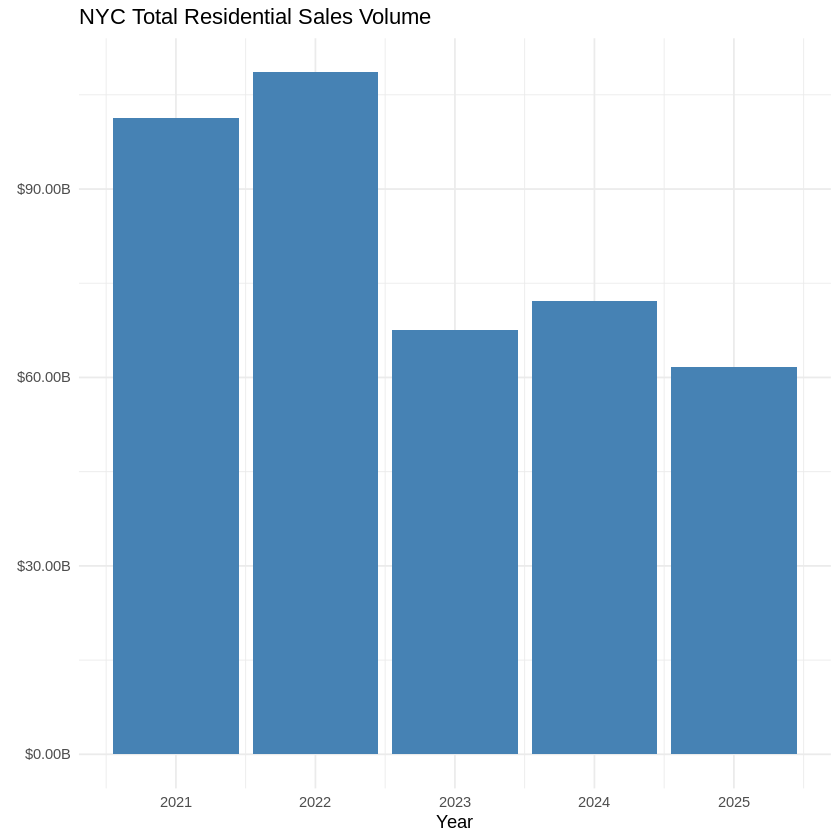

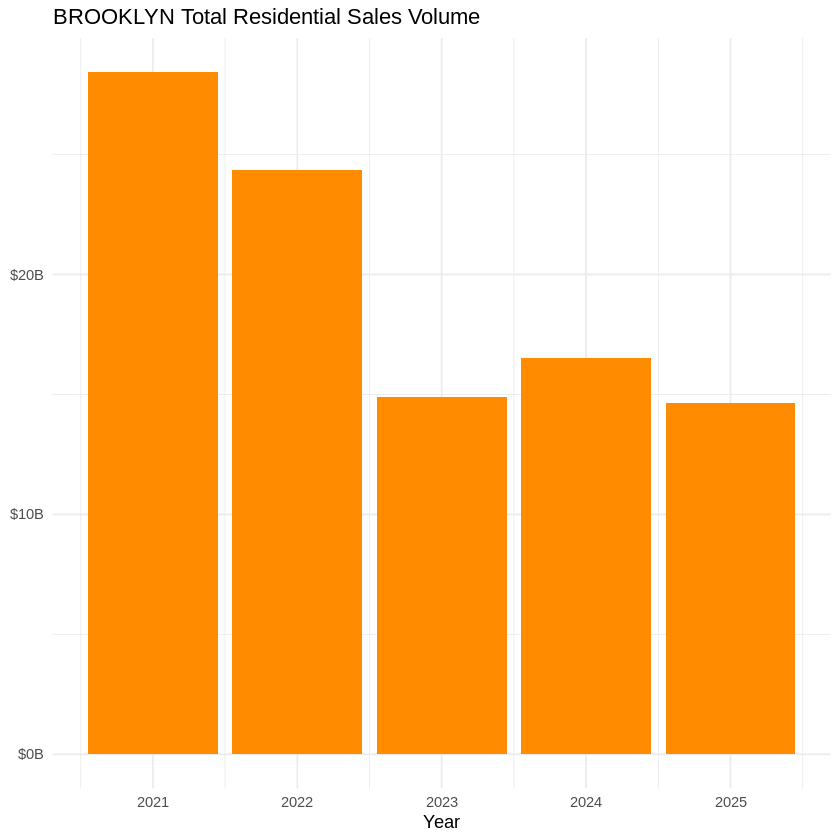

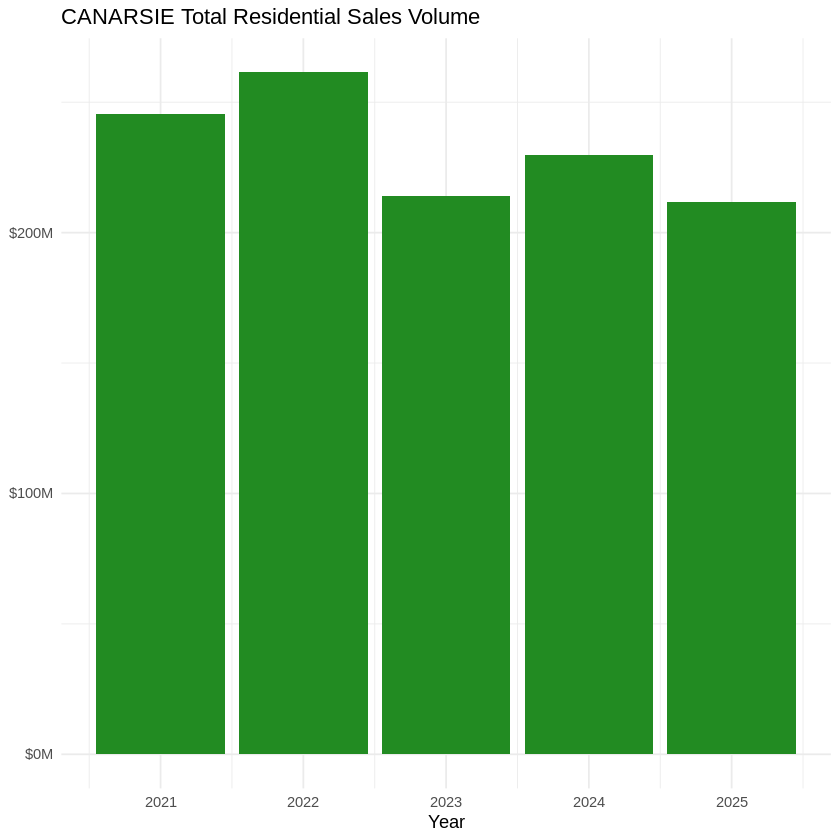

In [ ]:
# ----- 1A. Total Residential Sales Volume by Year -----
# SALE_PRICE > 0 here just excludes $0 from totals; it is NOT the full cleaning step.

nyc_volume <- df %>%
  filter(SALE_YEAR %in% RECENT_YEARS, SALE_PRICE > 0,
         str_detect(TYPE, "RESIDENTIAL")) %>%  # TODO: verify label
  group_by(SALE_YEAR) %>%
  summarise(total_volume = sum(SALE_PRICE, na.rm = TRUE), n_sales = n())

borough_volume <- df %>%
  filter(SALE_YEAR %in% RECENT_YEARS, SALE_PRICE > 0, BOROUGH_NAME == MY_BOROUGH,
         str_detect(TYPE, "RESIDENTIAL")) %>%
  group_by(SALE_YEAR) %>%
  summarise(total_volume = sum(SALE_PRICE, na.rm = TRUE), n_sales = n())

nbhd_volume <- df %>%
  filter(SALE_YEAR %in% RECENT_YEARS, SALE_PRICE > 0, NEIGHBORHOOD_NAME == MY_NEIGHBORHOOD,
         str_detect(TYPE, "RESIDENTIAL")) %>%
  group_by(SALE_YEAR) %>%
  summarise(total_volume = sum(SALE_PRICE, na.rm = TRUE), n_sales = n())

ggplot(nyc_volume, aes(x = SALE_YEAR, y = total_volume)) +
  geom_col(fill = "steelblue") +
  scale_y_continuous(labels = label_dollar(scale = 1e-9, suffix = "B")) +
  labs(title = "NYC Total Residential Sales Volume", x = "Year", y = NULL) + theme_minimal()

ggplot(borough_volume, aes(x = SALE_YEAR, y = total_volume)) +
  geom_col(fill = "darkorange") +
  scale_y_continuous(labels = label_dollar(scale = 1e-9, suffix = "B")) +
  labs(title = paste(MY_BOROUGH, "Total Residential Sales Volume"), x = "Year", y = NULL) + theme_minimal()

ggplot(nbhd_volume, aes(x = SALE_YEAR, y = total_volume)) +
  geom_col(fill = "forestgreen") +
  scale_y_continuous(labels = label_dollar(scale = 1e-6, suffix = "M")) +
  labs(title = paste(MY_NEIGHBORHOOD, "Total Residential Sales Volume"), x = "Year", y = NULL) + theme_minimal()

The NYC market experienced a slight cooling and stabilization between 2023 and 2025 following the post-COVID
spike. The borough of Brooklyn largely mirrored this citywide trend. In contrast, the Canarsie neighborhood
maintained a relatively stable volume, effectively outperforming the broader market and solidifying its reputation
as a consistent middle-market residential hub.

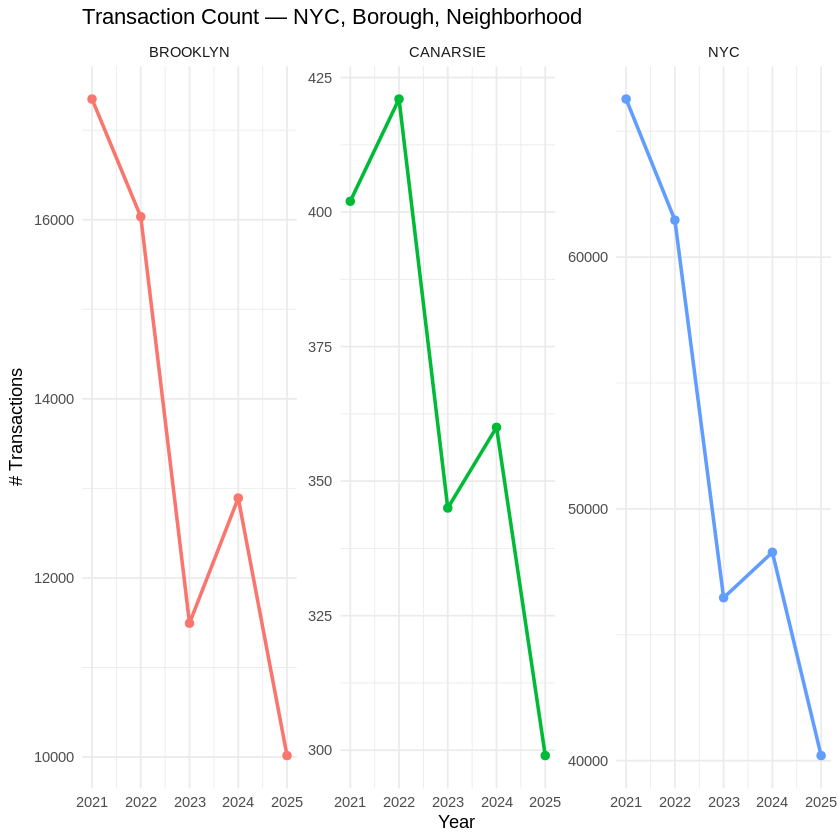

In [ ]:
# ----- 1B. Transaction Count by Year -----
txn_compare <- bind_rows(
  nyc_volume     %>% mutate(level = "NYC"),
  borough_volume %>% mutate(level = MY_BOROUGH),
  nbhd_volume    %>% mutate(level = MY_NEIGHBORHOOD)
)
ggplot(txn_compare, aes(x = SALE_YEAR, y = n_sales, color = level, group = level)) +
  geom_line(linewidth = 1) + geom_point(size = 2) +
  facet_wrap(~level, scales = "free_y") +
  labs(title = "Transaction Count — NYC, Borough, Neighborhood",
       x = "Year", y = "# Transactions") +
  theme_minimal() + theme(legend.position = "none")

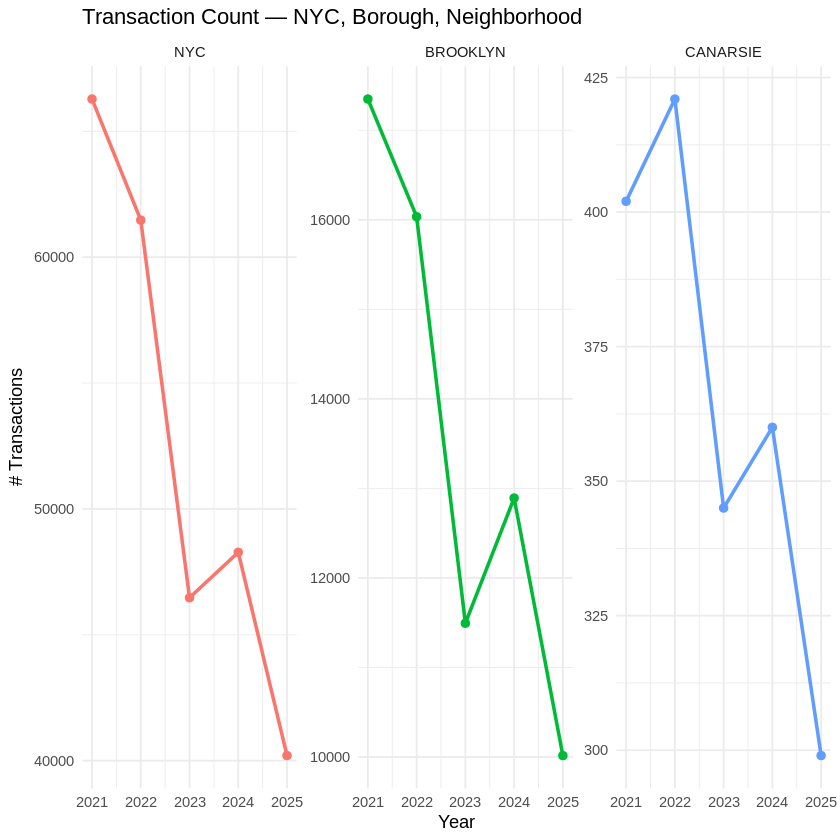

In [ ]:
# ----- 1B. Transaction Count by Year -----
txn_compare <- bind_rows (
  nyc_volume     %>% mutate ( level = "NYC" ),
  borough_volume %>% mutate ( level = MY_BOROUGH ),
  nbhd_volume    %>% mutate ( level = MY_NEIGHBORHOOD )
)

# Fix the order so NYC shows first, then Borough, then Neighborhood
txn_compare$level <- factor(txn_compare$level, levels = c("NYC", MY_BOROUGH, MY_NEIGHBORHOOD))

ggplot ( txn_compare , aes ( x = SALE_YEAR , y = n_sales , color = level , group = level ) ) +
  geom_line ( linewidth = 1 ) +
  geom_point ( size = 2 ) +
  facet_wrap ( ~level , scales = "free_y" ) +
  labs ( title = "Transaction Count — NYC, Borough, Neighborhood" ,
         x = "Year" , y = "# Transactions" ) +
  theme_minimal ( ) +
  theme ( legend.position = "none" )

Canarsie has proven to be much more resilient than the rest of the city.
While home sales across NYC and Brooklyn nearly dropped by half
after the 2021 peak, Canarsie’s numbers stayed relatively steady. This
stability shows that the neighborhood remains a high-demand spot for
middle-market buyers, even when the broader market slows down.

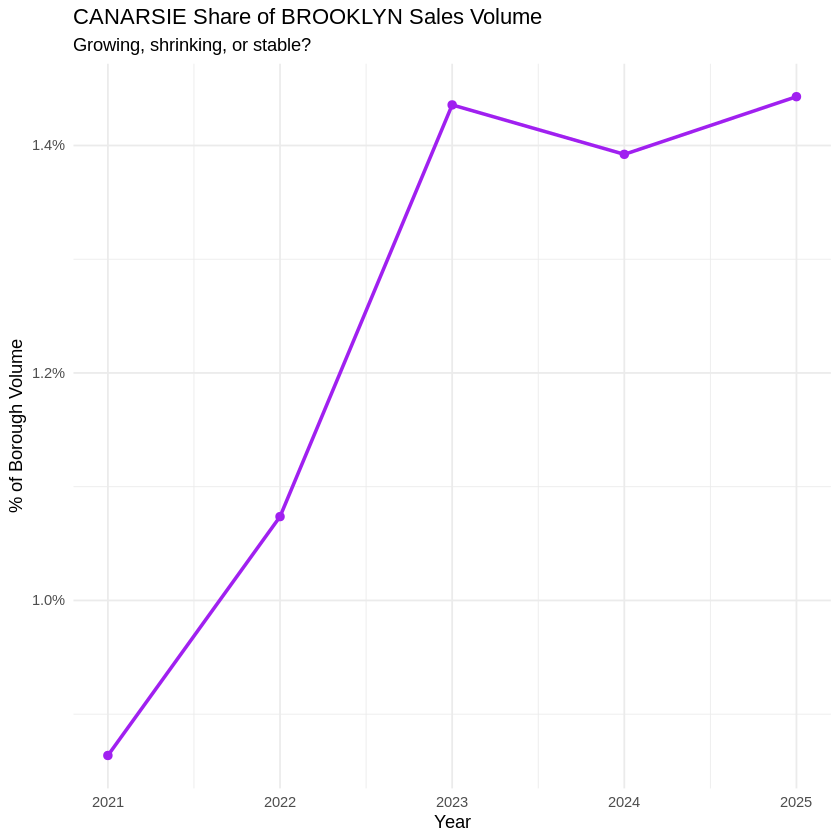

In [ ]:
# ----- 1C. Neighborhood Share of Borough Volume -----
share_data <- borough_volume %>%
  rename(borough_vol = total_volume) %>%
  left_join(nbhd_volume %>% rename(nbhd_vol = total_volume), by = "SALE_YEAR") %>%
  mutate(share_pct = nbhd_vol / borough_vol * 100)

ggplot(share_data, aes(x = SALE_YEAR, y = share_pct)) +
  geom_line(color = "purple", linewidth = 1) + geom_point(size = 2, color = "purple") +
  scale_y_continuous(labels = label_percent(scale = 1)) +
  labs(title = paste(MY_NEIGHBORHOOD, "Share of", MY_BOROUGH, "Sales Volume"),
       subtitle = "Growing, shrinking, or stable?",
       x = "Year", y = "% of Borough Volume") + theme_minimal()
# TODO (writing): Describe the trend.

Canarsie currently accounts for a small ~1% share of Brooklyn’s total sales
volume, its market presence has shown consistent growth over the last five
years, rising from ~1% in 2021 to more than 1.4% in 2025. This upward
trend shows that while the total Brooklyn market has slowed, Canarsie is
showing growing sales volume.

# A tibble: 5 × 3
  TYPE            n    pct
  <chr>       <int>  <dbl>
1 RESIDENTIAL 11505 92.7  
2 COMMERCIAL    628  5.06 
3 MIXED         187  1.51 
4 OTHER          68  0.548
5 NA             23  0.185


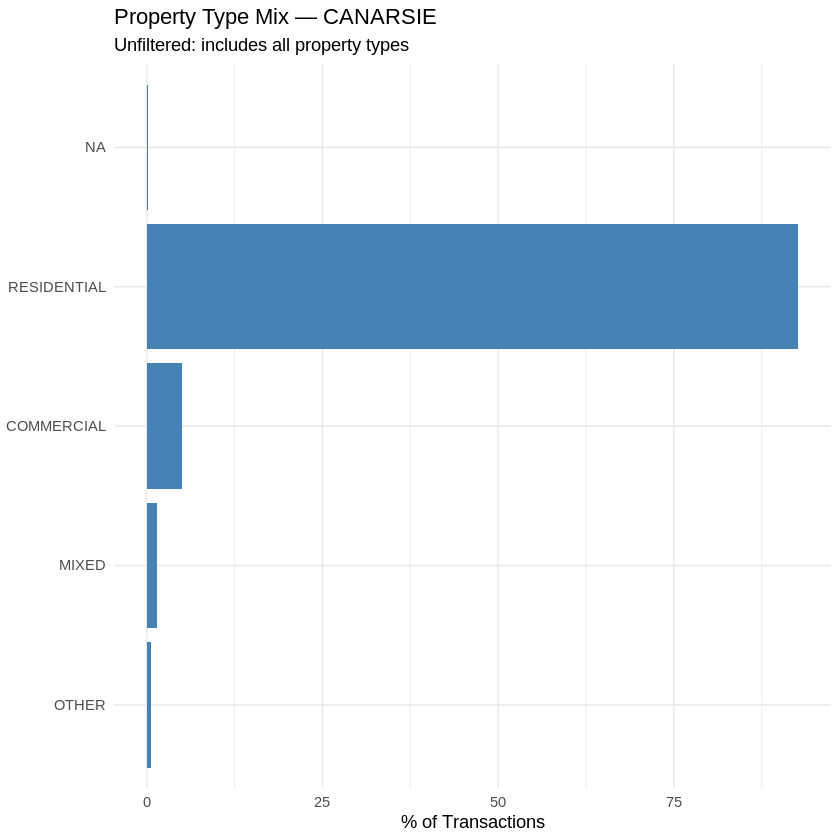

In [ ]:
# ----- 1D. Property Type Mix — INTENTIONALLY UNFILTERED -----
# Do NOT apply residential-only filter here.
type_mix <- df %>%
  filter(NEIGHBORHOOD_NAME == MY_NEIGHBORHOOD, SALE_PRICE > 0) %>%
  count(TYPE) %>%
  mutate(pct = n / sum(n) * 100) %>%
  arrange(desc(n))

ggplot(type_mix %>% head(10), aes(x = reorder(TYPE, n), y = pct)) +
  geom_col(fill = "steelblue") + coord_flip() +
  labs(title = paste("Property Type Mix —", MY_NEIGHBORHOOD),
       subtitle = "Unfiltered: includes all property types",
       x = NULL, y = "% of Transactions") + theme_minimal()
print(type_mix)
# TODO (writing): What does the mix tell you about the market?

Canarsie is a dedicated residential naberhood, with nearly 92.7% of all
market activity driven by home sales. Commercial represents only 5.06%.

In [ ]:
n_before <- nrow(df)
cat("Rows BEFORE cleaning (full NYC):", n_before, "\n")

df_clean <- df %>%
  filter(
    str_detect(TYPE, "RESIDENTIAL"),  # TODO: verify label
    SALE_PRICE        > 0,
    GROSS_SQUARE_FEET > 0
  ) %>%
  mutate(PRICE_PER_SQFT = SALE_PRICE / GROSS_SQUARE_FEET)

n_after <- nrow(df_clean)
cat("Rows AFTER cleaning (df_clean):", n_after, "\n")
cat("Removed:", n_before - n_after,
    sprintf("(%.1f%%)", (n_before - n_after) / n_before * 100), "\n")

Rows BEFORE cleaning (full NYC): 2083757 
Rows AFTER cleaning (df_clean): 643835 
Removed: 1439922 (69.1%) 


In [ ]:
nbhd_clean <- df_clean %>%
  filter(NEIGHBORHOOD_NAME == MY_NEIGHBORHOOD, SALE_YEAR >= 2009,
  SALE_PRICE >= 10000,
  GROSS_SQUARE_FEET < quantile(GROSS_SQUARE_FEET, 0.98, na.rm = TRUE))

cat("df_clean   — full NYC cleaned:          ", nrow(df_clean),  "rows\n")
cat("nbhd_clean — your neighborhood (2009+):", nrow(nbhd_clean), "rows\n")
summary(nbhd_clean$PRICE_PER_SQFT)

df_clean   — full NYC cleaned:           643835 rows
nbhd_clean — your neighborhood (2009+): 5580 rows


    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
   2.899  204.750  279.487  300.335  378.788 1847.235 

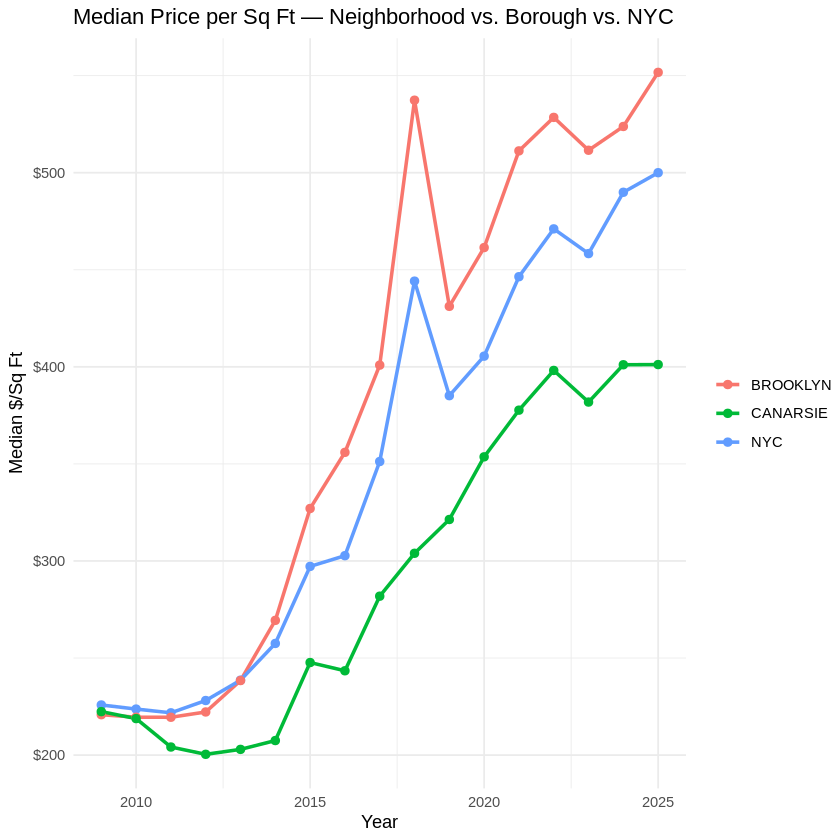

In [ ]:
# ----- 3A. PSF Trend — exception: needs all three levels from df_clean -----
psf_nyc <- df_clean %>% filter(SALE_YEAR >= 2009) %>%
  group_by(SALE_YEAR) %>%
  summarise(median_psf = median(PRICE_PER_SQFT, na.rm = TRUE)) %>% mutate(level = "NYC")

psf_borough <- df_clean %>% filter(SALE_YEAR >= 2009, BOROUGH_NAME == MY_BOROUGH) %>%
  group_by(SALE_YEAR) %>%
  summarise(median_psf = median(PRICE_PER_SQFT, na.rm = TRUE)) %>% mutate(level = MY_BOROUGH)

psf_nbhd <- nbhd_clean %>%
  group_by(SALE_YEAR) %>%
  summarise(median_psf = median(PRICE_PER_SQFT, na.rm = TRUE)) %>% mutate(level = MY_NEIGHBORHOOD)

bind_rows(psf_nyc, psf_borough, psf_nbhd) %>%
  ggplot(aes(x = SALE_YEAR, y = median_psf, color = level, group = level)) +
  geom_line(linewidth = 1) + geom_point(size = 2) +
  scale_y_continuous(labels = label_dollar()) +
  labs(title = "Median Price per Sq Ft — Neighborhood vs. Borough vs. NYC",
       x = "Year", y = "Median $/Sq Ft", color = NULL) + theme_minimal()

The price per square foot trend highlights Canarsie’s competitive advantage
as an affordable residential entry point. While NYC and Brooklyn have seen
steady price per square foot growth over the last decade, Canarsie’s
median price per square foot remains significantly lower than the borough
and city averages. This gap confirms that Canarsie offers more affordable
house attracting buyers who are priced out of more expensive Brooklyn
hubs.
In Canarsie, the average home price of $535,838 is nearly identical to the
median of $525,000. Even though the gap is very small (only 2.1%), there
are a few houses in Canarsie that sold for much higher prices than the rest
of the neighborhood. These expensive homes pulls distribution skewed right
(positively skewed).

In [ ]:
# ----- 3B-3E: nbhd_clean only -----

# 3B. Mean vs Median
mean_price   <- mean(nbhd_clean$SALE_PRICE, na.rm = TRUE)
median_price <- median(nbhd_clean$SALE_PRICE, na.rm = TRUE)
gap_pct      <- (mean_price - median_price) / median_price * 100
cat(sprintf("Mean:   $%s\n", format(round(mean_price),   big.mark = ",")))
cat(sprintf("Median: $%s\n", format(round(median_price), big.mark = ",")))
cat(sprintf("Gap: $%s  (%.1f%% above median)\n",
            format(round(mean_price - median_price), big.mark = ","), gap_pct))

Mean:   $535,838
Median: $525,000
Gap: $10,838  (2.1% above median)


    Min      Q1  Median      Q3     Max 
  10000  380188  525000  675000 8150000 


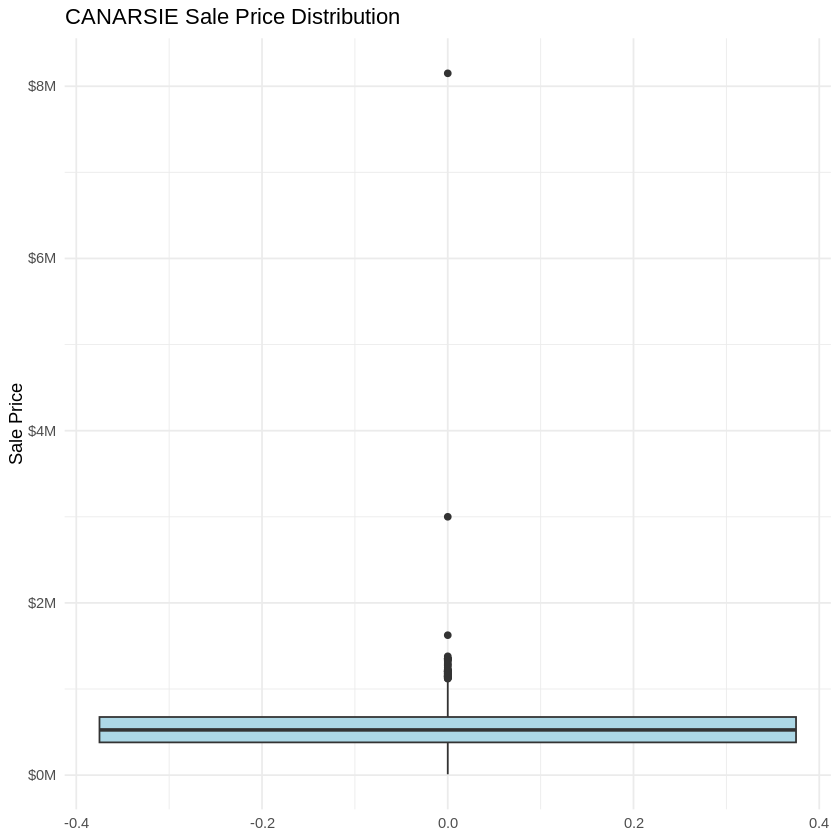

In [ ]:
# 3C. Five-number summary
five_num <- quantile(nbhd_clean$SALE_PRICE, probs = c(0,.25,.5,.75,1), na.rm = TRUE)
names(five_num) <- c("Min","Q1","Median","Q3","Max")
print(round(five_num))

ggplot(nbhd_clean, aes(y = SALE_PRICE)) +
  geom_boxplot(fill = "lightblue") +
  scale_y_continuous(labels = label_dollar(scale = 1e-6, suffix = "M")) +
  labs(title = paste(MY_NEIGHBORHOOD, "Sale Price Distribution"), y = "Sale Price") +
  theme_minimal()

In [ ]:
# 3D. SD and CV
sd_price <- sd(nbhd_clean$SALE_PRICE, na.rm = TRUE)
cv_price <- sd_price / mean_price
cat(sprintf("SD: $%s\n", format(round(sd_price), big.mark = ",")))
cat(sprintf("CV: %.2f  — %s\n", cv_price,
    ifelse(cv_price > 1, "CV > 1.0: highly variable (high price risk)",
                         "CV < 1.0: relatively stable pricing")))

SD: $249,090
CV: 0.46  — CV < 1.0: relatively stable pricing


Pearson r (price vs sq ft): 0.326


`geom_smooth()` using formula = 'y ~ x'


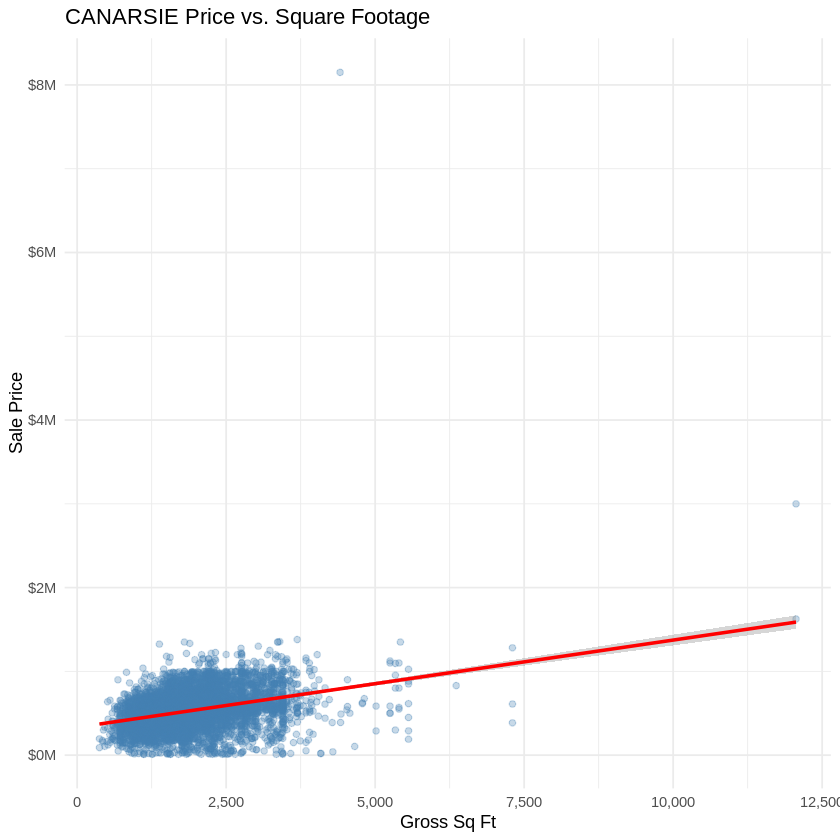

In [ ]:
# 3E. Correlation
cor_val <- cor(nbhd_clean$SALE_PRICE, nbhd_clean$GROSS_SQUARE_FEET, use = "complete.obs")
cat(sprintf("Pearson r (price vs sq ft): %.3f\n", cor_val))

ggplot(nbhd_clean, aes(x = GROSS_SQUARE_FEET, y = SALE_PRICE)) +
  geom_point(alpha = 0.3, color = "steelblue") +
  geom_smooth(method = "lm", se = TRUE, color = "red") +
  scale_y_continuous(labels = label_dollar(scale = 1e-6, suffix = "M")) +
  scale_x_continuous(labels = label_comma()) +
  labs(title = paste(MY_NEIGHBORHOOD, "Price vs. Square Footage"),
       x = "Gross Sq Ft", y = "Sale Price") + theme_minimal()

**Clustering Part 1: Strategic Market Positioning**

In [ ]:
nbhd_agg <- df_clean %>%
  filter(SALE_YEAR >= 2009) %>%
  group_by(NEIGHBORHOOD_NAME) %>%
  summarise(
    median_price = median(SALE_PRICE,     na.rm = TRUE),
    total_sales  = n(),
    median_psf   = median(PRICE_PER_SQFT, na.rm = TRUE),
    sd_price     = sd(SALE_PRICE,         na.rm = TRUE)   # market volatility
  ) %>%
  filter(!is.na(median_psf), total_sales >= 2)
cat("Neighborhoods:", nrow(nbhd_agg), "\n")
head(nbhd_agg)

Neighborhoods: 256 


NEIGHBORHOOD_NAME,median_price,total_sales,median_psf,sd_price
<chr>,<dbl>,<int>,<dbl>,<dbl>
AIRPORT LA GUARDIA,742500,54,534.8288,239540.2
ALPHABET CITY,3400000,320,550.6708,9872151.5
ANNADALE,699000,1673,317.6471,376202.8
ARDEN HEIGHTS,400000,3016,267.5608,189631.0
ARROCHAR,525000,291,318.5433,247964.5
ARROCHAR-SHORE ACRES,543800,171,333.3333,343544.5


In [ ]:
my_nbhd_agg <- df_clean %>%
  filter(SALE_YEAR >= 2009) %>%
  filter(NEIGHBORHOOD_NAME == MY_NEIGHBORHOOD) %>%
  group_by(NEIGHBORHOOD_NAME) %>%
  summarise(
    median_price = median(SALE_PRICE,        na.rm = TRUE),
    total_sales  = n(),
    median_psf   = median(PRICE_PER_SQFT,    na.rm = TRUE),
    sd_price     = sd(SALE_PRICE,            na.rm = TRUE),
    avg_sqft     = mean(GROSS_SQUARE_FEET,   na.rm = TRUE)   # <-- Added this line
  ) %>%
  filter(!is.na(median_psf), total_sales >= 2)

my_nbhd_agg

NEIGHBORHOOD_NAME,median_price,total_sales,median_psf,sd_price,avg_sqft
<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
CANARSIE,503500,5955,268.4049,469218.5,2024.976


In [ ]:
# Z-score scale — required: without this SALE_PRICE dominates completely
nbhd_scaled <- nbhd_agg %>%
  select(median_price, total_sales, median_psf, sd_price) %>%
  scale()
rownames(nbhd_scaled) <- nbhd_agg$NEIGHBORHOOD_NAME
apply(nbhd_scaled, 2, function(x) c(mean = round(mean(x),6), sd = round(sd(x),3)))

,median_price,total_sales,median_psf,sd_price
mean,0,0,0,0
sd,1,1,1,1


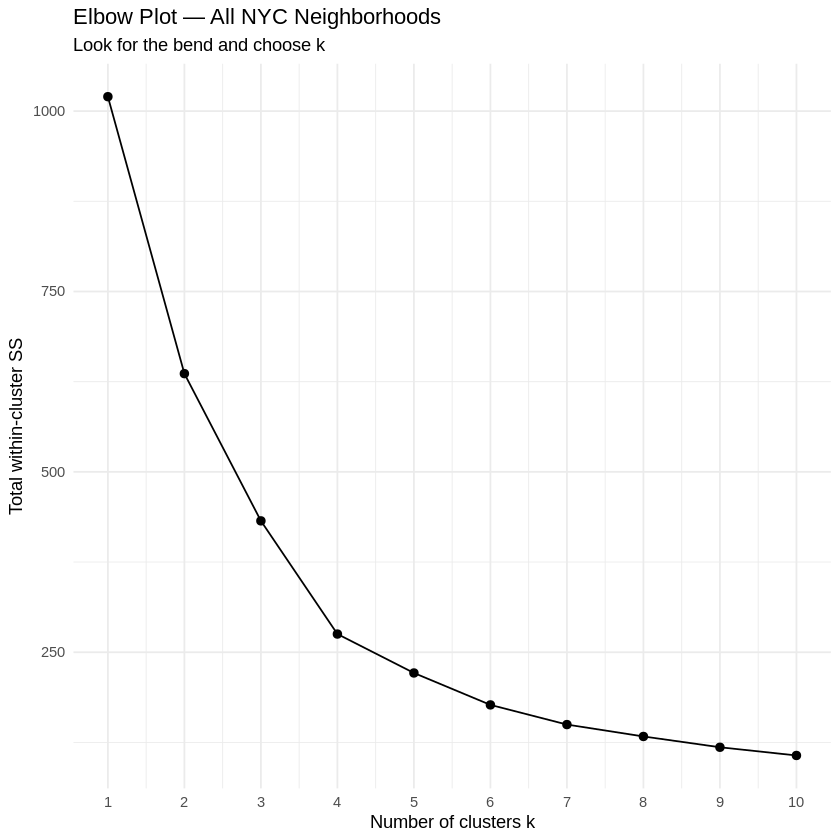

In [ ]:
# Elbow plot — no external packages needed, just purrr (loaded with tidyverse)
wss <- map_dbl(1:10, ~ kmeans(nbhd_scaled, centers = .x, nstart = 25)$tot.withinss)

tibble(k = 1:10, wss = wss) %>%
  ggplot(aes(x = k, y = wss)) +
  geom_line() + geom_point(size = 2) +
  scale_x_continuous(breaks = 1:10) +
  labs(title = "Elbow Plot — All NYC Neighborhoods",
       subtitle = "Look for the bend and choose k",
       x = "Number of clusters k", y = "Total within-cluster SS") +
  theme_minimal()
# TODO: What value of k do you choose and why?

In [ ]:
K1 <- 3   # TODO: Replace with your chosen k; I used 3

set.seed(42)
km1 <- kmeans(nbhd_scaled, centers = K1, nstart = 25)
nbhd_agg <- nbhd_agg %>% mutate(cluster = factor(km1$cluster))

nbhd_agg %>%
  group_by(cluster) %>%
  summarise(n = n(),
            avg_median_price = mean(median_price),
            avg_total_sales  = mean(total_sales),
            avg_median_psf   = mean(median_psf)) %>% print()
# TODO: Label each cluster in plain English

# A tibble: 3 × 5
  cluster     n avg_median_price avg_total_sales avg_median_psf
  <fct>   <int>            <dbl>           <dbl>          <dbl>
1 1         167          805073.           1004.           355.
2 2          50          643079.           4564.           337.
3 3          39         3672112.            439.          1190.


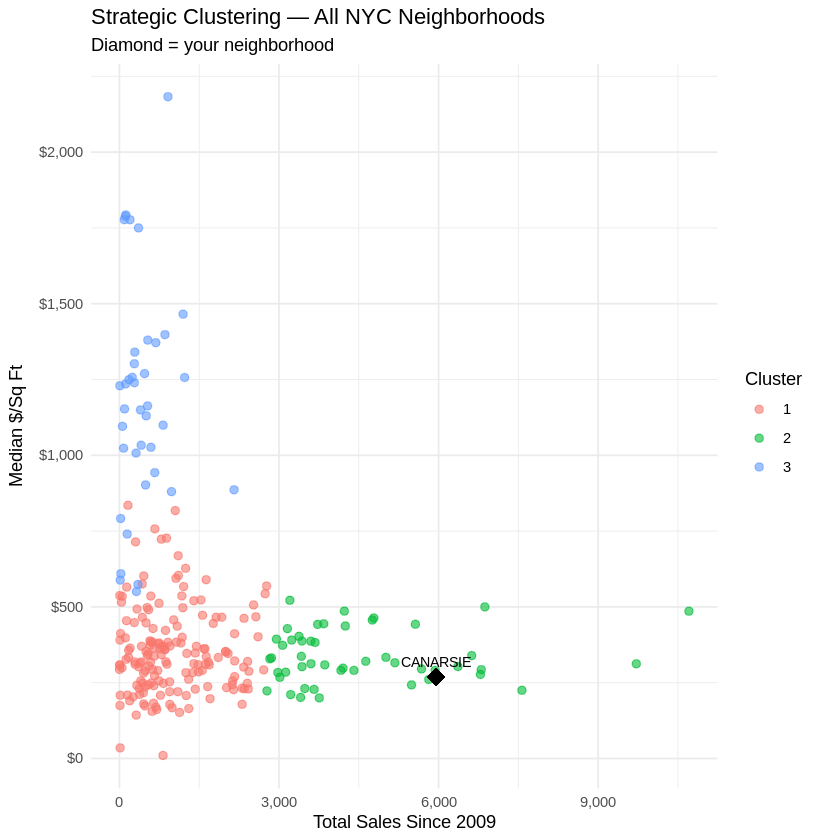

In [ ]:
ggplot(nbhd_agg, aes(x = total_sales, y = median_psf, color = cluster)) +
  geom_point(alpha = 0.6, size = 2) +
  geom_point(data = filter(nbhd_agg, NEIGHBORHOOD_NAME == MY_NEIGHBORHOOD),
             color = "black", size = 5, shape = 18) +
  geom_text(data = filter(nbhd_agg, NEIGHBORHOOD_NAME == MY_NEIGHBORHOOD),
            aes(label = NEIGHBORHOOD_NAME), vjust = -1, color = "black", size = 3) +
  scale_y_continuous(labels = label_dollar()) +
  scale_x_continuous(labels = label_comma()) +
  labs(title = "Strategic Clustering — All NYC Neighborhoods",
       subtitle = "Diamond = your neighborhood",
       x = "Total Sales Since 2009", y = "Median $/Sq Ft", color = "Cluster") +
  theme_minimal()

1. Budget Basics: Represents reliable, multi-family residential areas with prices slightly higher Mid-Market
and consistent sales volume.
2. Mid-Market: Cluster includes Canarsie, is the most liquid part of the market, featuring the highest
transaction counts.
3. Luxury: Exclusive, low-volume neighborhoods where the price per square foot is nearly four times higher
than the other clusters ($1,190 vs ~$340).

In [ ]:
my_row <- nbhd_agg %>% filter(NEIGHBORHOOD_NAME == MY_NEIGHBORHOOD)
cat("Neighborhood:", MY_NEIGHBORHOOD, "\n")
cat("Cluster:",      as.character(my_row$cluster), "\n")
cat("Median price:", dollar(my_row$median_price), "\n")
cat("Median $/sqft:",dollar(my_row$median_psf), "\n")
A5_BENCHMARK_PRICE <- my_row$median_price
A5_BENCHMARK_PSF   <- my_row$median_psf

Neighborhood: CANARSIE 
Cluster: 2 
Median price: $503,500 
Median $/sqft: $268.40 


In [ ]:
# Peer neighborhoods — same cluster as yours
peers <- nbhd_agg %>%
  filter(cluster == my_row$cluster, NEIGHBORHOOD_NAME != MY_NEIGHBORHOOD) %>%
  arrange(abs(median_psf - my_row$median_psf)) %>%   # closest in $/sqft first
  head(5) %>%
  select(NEIGHBORHOOD_NAME, median_price, total_sales, median_psf)

cat("Your 5 closest peer neighborhoods in the same cluster:\n")
print(peers)

Your 5 closest peer neighborhoods in the same cluster:
# A tibble: 5 × 4
  NEIGHBORHOOD_NAME median_price total_sales median_psf
  <chr>                    <dbl>       <int>      <dbl>
1 ARDEN HEIGHTS           400000        3016       268.
2 SOUTH JAMAICA           389000        5815       261.
3 ST. ALBANS              415000        6787       277.
4 THROGS NECK             495000        2978       284.
5 RIDGEWOOD               814199        3125       285.


In [ ]:

# Top 5 closest peer neighborhoods in Cluster 1
cluster_1_peers <- nbhd_agg %>%
  filter(cluster == 1) %>%
  arrange(abs(median_psf - my_row$median_psf)) %>%
  head(5) %>%
  select(NEIGHBORHOOD_NAME, median_price, total_sales, median_psf)

print(cluster_1_peers)
# Top 5 closest peer neighborhoods in Cluster 2
cluster_2_peers <- nbhd_agg %>%
  filter(cluster == 2, NEIGHBORHOOD_NAME != "CANARSIE") %>%
  arrange(abs(median_psf - 268.40)) %>%
  head(5) %>%
  select(NEIGHBORHOOD_NAME, median_price, total_sales, median_psf)

print(cluster_2_peers)

# Top 5 contrast neighborhoods in Cluster 3 (Highest PSF)
cluster_3_contrast <- nbhd_agg %>%
  filter(cluster == 3) %>%
  arrange(desc(median_psf)) %>%
  head(5) %>%
  select(NEIGHBORHOOD_NAME, median_price, total_sales, median_psf)

print(cluster_3_contrast)

# A tibble: 5 × 4
  NEIGHBORHOOD_NAME        median_price total_sales median_psf
  <chr>                           <dbl>       <int>      <dbl>
1 SCHUYLERVILLE/PELHAM BAY       550000        2165       270.
2 PELHAM PARKWAY SOUTH           595000         659       273.
3 PELHAM PARKWAY NORTH           523000        1301       261.
4 WYCKOFF HEIGHTS                900000         742       256.
5 MORRIS PARK/VAN NEST           542000        2129       256.
# A tibble: 5 × 4
  NEIGHBORHOOD_NAME median_price total_sales median_psf
  <chr>                    <dbl>       <int>      <dbl>
1 ARDEN HEIGHTS           400000        3016       268.
2 SOUTH JAMAICA           389000        5815       261.
3 ST. ALBANS              415000        6787       277.
4 THROGS NECK             495000        2978       284.
5 RIDGEWOOD               814199        3125       285.
# A tibble: 5 × 4
  NEIGHBORHOOD_NAME      median_price total_sales median_psf
  <chr>                         <dbl>       <int>   

Clustering Part 2: Property Segmentation

In [ ]:
nbhd_props <- nbhd_clean %>%
  select(SALE_PRICE, GROSS_SQUARE_FEET, RESIDENTIAL_UNITS) %>%
  drop_na()
cat("Transactions for segmentation:", nrow(nbhd_props), "\n")

Transactions for segmentation: 5580 


In [ ]:
props_scaled <- scale(nbhd_props)
apply(props_scaled, 2, function(x) c(mean = round(mean(x),6), sd = round(sd(x),3)))

,SALE_PRICE,GROSS_SQUARE_FEET,RESIDENTIAL_UNITS
mean,0,0,0
sd,1,1,1


In [ ]:
K2 <- 3   # Fixed — no elbow plot needed for Part 2

set.seed(42)
km2 <- kmeans(props_scaled, centers = K2, nstart = 25)
nbhd_props <- nbhd_props %>% mutate(segment = factor(km2$cluster))

nbhd_props %>%
  group_by(segment) %>%
  summarise(
    n         = n(),
    pct       = round(n() / nrow(nbhd_props) * 100, 1),
    med_price = median(SALE_PRICE),
    med_sqft  = median(GROSS_SQUARE_FEET),
    med_units = median(RESIDENTIAL_UNITS)
  ) %>% print()
# TODO: Label each segment (e.g., 'Small single-family', 'Mid-size 2-4 family', 'Large multifamily')

# A tibble: 3 × 6
  segment     n   pct med_price med_sqft med_units
  <fct>   <int> <dbl>     <dbl>    <dbl>     <dbl>
1 1        2695  48.3   478091      1764         2
2 2        1448  25.9   744740.     2760         2
3 3        1437  25.8   415000      1201         1


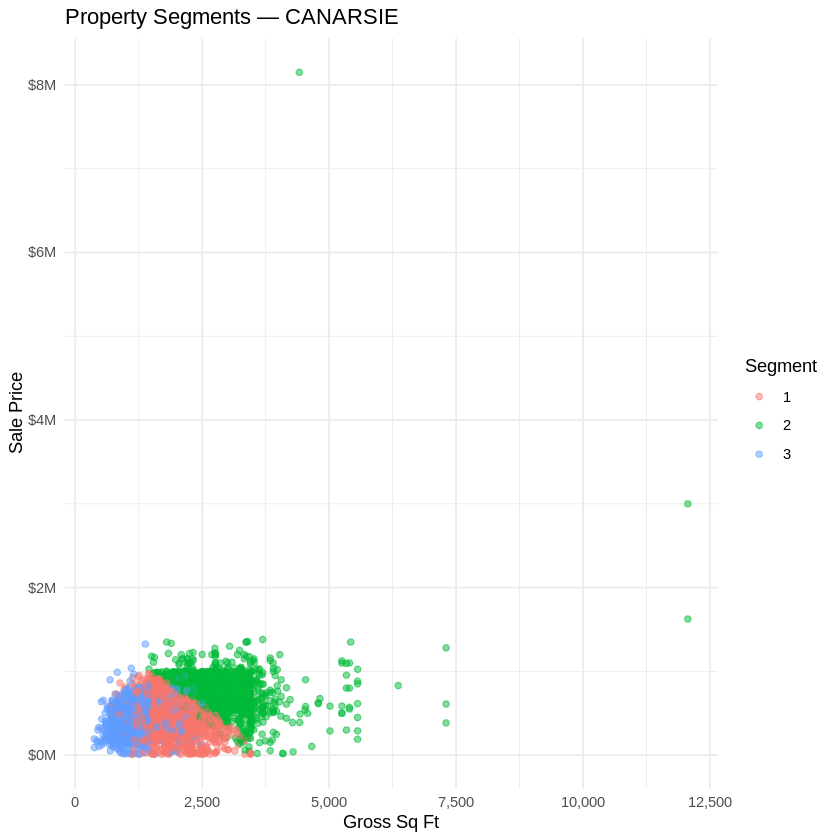

In [ ]:
ggplot(nbhd_props, aes(x = GROSS_SQUARE_FEET, y = SALE_PRICE, color = segment)) +
  geom_point(alpha = 0.5, size = 1.5) +
  scale_y_continuous(labels = label_dollar(scale = 1e-6, suffix = "M")) +
  scale_x_continuous(labels = label_comma()) +
  labs(title = paste("Property Segments —", MY_NEIGHBORHOOD),
       x = "Gross Sq Ft", y = "Sale Price", color = "Segment") +
  theme_minimal()
# TODO (writing): Which segment should a new brokerage focus on, and why?

1. Standard. Representing 48.3% of the neighborhood, these are the typical two-family homes (median
1,764 sq ft) that form the backbone of Canarsie’s residential market.

2. Premium. Representing 25.9% of the neighborhood. The larger multi-unit properties (median 2,760 sq ft).
They have the highest prices $744k.

3. Entry. Representing 25.8% of the neighborhood. Consisting of single-family starter homes (median 1,201
sq ft), this segment offers the lowest price point ($415k) and is ideal for first-time homebuyers.

In [ ]:
MOST_RECENT_YEAR <- max(nbhd_clean$SALE_YEAR, na.rm = TRUE)
COMMISSION_RATE  <- 0.05
MARKET_SHARE     <- 0.125

recent_sales    <- nbhd_clean %>% filter(SALE_YEAR == MOST_RECENT_YEAR)
total_volume    <- sum(recent_sales$SALE_PRICE, na.rm = TRUE)
commission_pool <- total_volume * COMMISSION_RATE
firm_revenue    <- commission_pool * MARKET_SHARE

cat("Year:", MOST_RECENT_YEAR, "| Transactions:", nrow(recent_sales), "\n")
cat("Total residential volume:    ", dollar(total_volume), "\n")
cat("Total commission pool (5%):  ", dollar(commission_pool), "\n")
cat("Firm revenue at 12.5% share: ", dollar(firm_revenue), "\n")

Year: 2025 | Transactions: 246 
Total residential volume:     $185,087,856 
Total commission pool (5%):   $9,254,393 
Firm revenue at 12.5% share:  $1,156,799 


In 2025, Canarsie generated $185,087,856 in total sales volume across 246 residential transactions. At a
standard 5% real estate commission rate, this created a total neighborhood commission pool of $9,254,393. By
successfully capturing a 12.5% market share, our new brokerage would secure $1,156,799 in annual gross
revenue, making the neighborhood a highly lucrative target.



**Paragraph 1 - Market overview:** What does the residential market look like, and how does it compare to the borough and NYC? Is the neighborhood share growing or shrinking?

**Paragraph 2 - Risk and statistical character:** What do mean vs. median and the CV tell you about price risk? Does square footage explain price well?

**Paragraph 3 - Strategic positioning and recommendation:** Which cluster does your neighborhood belong to? What do the property segments reveal about brokerage focus? Is the revenue opportunity compelling?

---
Canarsie stands out as a resilient residential naberhood within the broader New York City landscape. Canarsie maintained a stable transaction flow, effectively outperforming the broader market. Especially the last three years years from 2023 to 2025 when the NYC market experienced a slight cooling after the post-COVID spike. The borough of Brooklyn largely mirrored this citywide trend. In contrast, the Canarsie neighborhood maintained a relatively stable volume, effectively outperforming the broader market and solidifying its reputation as a consistent middle-market residential hub. The neighborhood is almost exclusively residential (92.7%), and its footprint within Brooklyn is expanding; its share of the borough’s total sales volume grew from around 1% in 2021 to over 1.4% by 2025.

Canarsie offers a highly predictable and stable pricing environment. The price risk is low, evidenced by a Coefficient of Variation of 0.41 and a very narrow gap of only 2.1% between the mean 535,838 USD and median 525,000 USD sale prices. This concentration suggests that most properties trade within a well-defined range, minimizing the danger of extreme price volatility. Interestingly, the correlation between building size and price is relatively weak (0.326), indicating that value in this market is less driven by raw square footage alone. For a brokerage, this means that neighborhood-specific knowledge will be more valuable than simple automated valuation models.

Canarsie sits in the NYC Mid-Market cluster, the most liquid segment of the city characterized by the highest transaction counts. Within the neighborhood, the clear target for a new brokerage is the Standard (Segment 1) category, which consists of two-family homes. This segment represents nearly half 48.3% of all local activity, providing the largest possible pool of listings and high liquidity. The revenue opportunity is compelling: in 2025 alone, the neighborhood generated over 9.2 million USD in available commissions. By capturing 12.5% market share, a new firm could secure approximately 1.15 million USD in annual gross revenue. Given the neighborhood's growth trend, stable risk profile, and high inventory turnover, Canarsie represents a high-conviction opportunity for immediate market entry.




# **A2**

# **________________**

In [ ]:
# Run  sort(unique(df$NEIGHBORHOOD))  to see the full list

MY_NEIGHBORHOOD <- "CANARSIE"   # <-- CHANGE THIS
IN_CLUSTER_NEIGHBORHOOD <- "ARDEN HEIGHTS" # <-- CHANGE THIS
OUT_CLUSTER_NEIGHBORHOOD <- "GREENWICH VILLAGE-WEST" # <-- CHANGE THIS


In [ ]:
RECENT_YEARS <- c(2021,2022,2023,2024,2025)

my_neighborhood_log_sales <-
  log(df %>%
  filter(
    SALE_YEAR %in% RECENT_YEARS,
    SALE_PRICE > 10000,
    GROSS_SQUARE_FEET > 100,
    NEIGHBORHOOD_NAME == MY_NEIGHBORHOOD,
    str_detect(TYPE, "RESIDENTIAL")
  ) %>%
  pull(SALE_PRICE))

in_cluster_neighborhood_log_sales <-
  log(df %>%
  filter(
    SALE_YEAR %in% RECENT_YEARS,
    SALE_PRICE > 10000,
    GROSS_SQUARE_FEET > 100,
    NEIGHBORHOOD_NAME == IN_CLUSTER_NEIGHBORHOOD,
    #str_detect(TYPE, "RESIDENTIAL")
  ) %>%
  pull(SALE_PRICE))

out_cluster_neighborhood_log_sales <-
  log(df %>%
  filter(
    SALE_YEAR %in% RECENT_YEARS,
    SALE_PRICE > 10000,
    GROSS_SQUARE_FEET > 100,
    NEIGHBORHOOD_NAME == OUT_CLUSTER_NEIGHBORHOOD,
    #str_detect(TYPE, "RESIDENTIAL")
  ) %>%
  pull(SALE_PRICE))


Run Two Sample t-test

In [ ]:
t.test(my_neighborhood_log_sales,in_cluster_neighborhood_log_sales)


	Welch Two Sample t-test

data:  my_neighborhood_log_sales and in_cluster_neighborhood_log_sales
t = 13.358, df = 2018.4, p-value < 2.2e-16
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 0.2071714 0.2784710
sample estimates:
mean of x mean of y 
 13.40557  13.16275 


Test 1: CANARSIE vs. ARDEN HEIGHTS (In-Cluster Peer)

Ho: The mean residential sale prices of Canarsie and Arden Heights are exactly equal.

P-value: < 2.2e-16 – we reject the null hypothesis at the 5% significance level.

Even though both neighborhoods sit in the same "Mid-Market" cluster, the price difference between them is
statistically real. Canarsie (mean price 13.41) commands a mathematically verified price slightly premium
over Arden Heights (mean price 13.16).

In [ ]:
t.test(my_neighborhood_log_sales,out_cluster_neighborhood_log_sales)


	Welch Two Sample t-test

data:  my_neighborhood_log_sales and out_cluster_neighborhood_log_sales
t = -53.835, df = 388.94, p-value < 2.2e-16
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -2.664681 -2.476907
sample estimates:
mean of x mean of y 
 13.40557  15.97636 


Test 2: Canarsie vs. Greenwich Village-West (Out-of-Cluster)

Ho: The mean residential sale prices of Canarsie and Greenwich Village-West are exactly equal.

P-value: < 2.2e-16 – we reject the null hypothesis at the 5% significance level.

The massive price difference is absolutely real. Greenwich Village-West (mean price 15.98) operates in an
entirely different financial reality than Canarsie (13.41), representing a vastly different buyer demographic
and market tier.

One Sample Confidence Interval

In [ ]:
my_neighborhood_sales_price <-
  df %>%
  filter(
    SALE_YEAR %in% RECENT_YEARS,
    SALE_PRICE > 10000,
    GROSS_SQUARE_FEET > 100,
    NEIGHBORHOOD_NAME == MY_NEIGHBORHOOD,
    str_detect(TYPE, "RESIDENTIAL")
  ) %>%
  pull(SALE_PRICE)

In [ ]:
t.test(my_neighborhood_sales_price)


	One Sample t-test

data:  my_neighborhood_sales_price
t = 122.83, df = 1478, p-value < 2.2e-16
alternative hypothesis: true mean is not equal to 0
95 percent confidence interval:
 708368.5 731360.9
sample estimates:
mean of x 
 719864.7 


Based on the one-sample t-test output, the 95% Confidence Interval for Canarsie's mean residential sale
price is $708,368.5 to $731,360.9. For a business owner or brokerage manager, this incredibly tight,
roughly $22,992.4 window is fantastic news. It proves that Canarsie offers a highly stable and predictable
transaction pool. Agents can accurately forecast their commission revenues without worrying about extreme,
unpredictable swings in the average home value.

Statistical testing confirms that while k-means effectively groups neighborhoods into broad, actionable
business tiers, significant micro-level price gaps exist even among peer markets. Specifically, Canarsie a
statistically proven, highly predictable price premium over its mid-market peer Arden Heights, while
operating in a completely different financial universe than the luxury tier of Greenwich Village-West.
The price differences suggested by our initial clustering hold up perfectly under rigorous statistical scrutiny,
but with an important caveat. The two-sample t-tests show that even though Canarsie and Arden Heights
belong to the same overarching "Mid-Market" cluster, their average prices are not strictly identical.
The test definitively rejected the null hypothesis, proving Canarsie's average prices are statistically higher.
Conversely, comparing Canarsie to out-of-cluster neighborhood, Greenwich Village-West, yielded massive
structural differences in mean price, confirming the clustering model successfully isolated the Manhattan
luxury market from Brooklyn's mid-market. For a brokerage thinking about expanding into nearby
neighborhoods, these statistical insights dictate a highly targeted strategy. Our confidence interval shows
Canarsie's average residential transactions reliably land between $708k and $731k, creating a highly
predictable pipeline for steady commission revenue.

# **A3**

# **_____________________**

In [ ]:
# ============================================================
# SECTION 2B: JOIN AND CLEAN DATA
# Apply the same cleaning rules you used in A1.
# ============================================================

# Filter: residential only, remove zero/missing prices and square footage
# These are the same rules from A1 — non-market transfers, not real sales
df_clean <- df %>%
  filter(
    TYPE == "RESIDENTIAL",       # residential properties only
    GROSS_SQUARE_FEET > 100,       # remove records with missing size
    SALE_YEAR >= 2009,
    GROSS_SQUARE_FEET <= 50000,    # removes implausible building sizes
    SALE_PRICE >= 50000         # removes partial interest transfers
    ) %>%
  mutate(
    PRICE_PER_SQFT = SALE_PRICE / GROSS_SQUARE_FEET  # our outcome variable
  )

cat("After cleaning:", nrow(df_clean), "residential transactions\n")
cat("Neighborhoods in dataset:", n_distinct(df_clean$NEIGHBORHOOD_NAME), "\n")

After cleaning: 390429 residential transactions
Neighborhoods in dataset: 258 


In [ ]:
# ============================================================
# SECTION 2C: SEPARATE YOUR NEIGHBORHOOD DATA
# ============================================================

df_hood <- df_clean %>%
  filter(NEIGHBORHOOD_NAME == MY_NEIGHBORHOOD)

cat("Transactions in", MY_NEIGHBORHOOD, ":", nrow(df_hood), "\n")

# Quick sanity check
if (nrow(df_hood) < 30) {
  warning("Very few transactions in your neighborhood. Check the spelling of MY_NEIGHBORHOOD.")
}

Transactions in CANARSIE : 5520 


Summary of PRICE_PER_SQFT after cleaning:


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  13.82  207.20  281.04  303.56  379.71 1847.23 

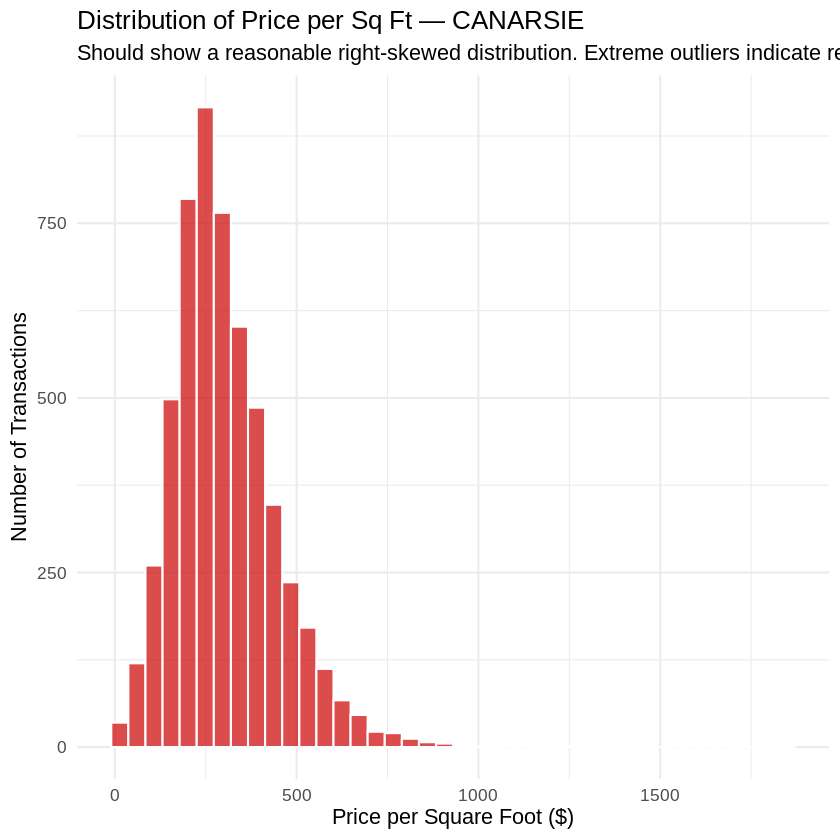

In [ ]:
# ============================================================
# DISTRIBUTION CHECK: PRICE PER SQUARE FOOT
# After our cleaning filters, the distribution should look
# reasonable — most values clustered in a sensible range
# for NYC residential real estate with a moderate right skew.
# If you still see extreme outliers (>$2000/sqft), revisit
# the cleaning filters above.
# ============================================================

ggplot(df_hood, aes(x = PRICE_PER_SQFT)) +
  geom_histogram(bins = 40, fill = "#CC0000", alpha = 0.7, color = "white") +
  labs(
    title    = paste("Distribution of Price per Sq Ft —", MY_NEIGHBORHOOD),
    subtitle = "Should show a reasonable right-skewed distribution. Extreme outliers indicate remaining data issues.",
    x        = "Price per Square Foot ($)",
    y        = "Number of Transactions"
  ) +
  theme_minimal(base_size = 13)

cat("Summary of PRICE_PER_SQFT after cleaning:\n")
summary(df_hood$PRICE_PER_SQFT)

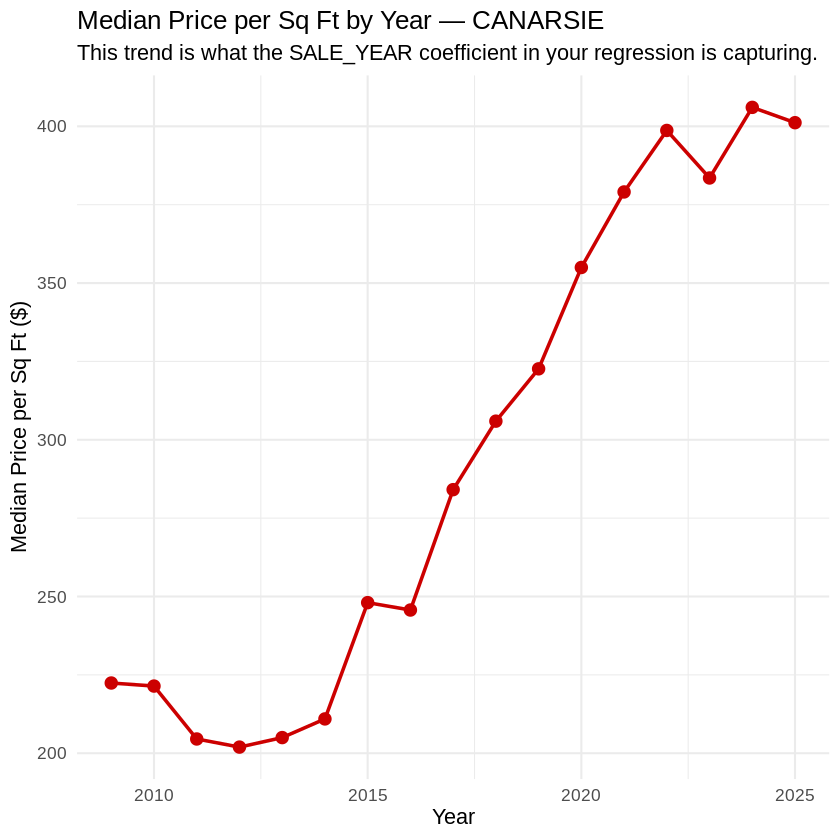

In [ ]:
# ============================================================
# PRICE PER SQFT OVER TIME
# Plot the annual trend in median price per sqft for your
# neighborhood. This gives you context for interpreting the
# regression coefficient on SALE_YEAR later.
# ============================================================

df_hood %>%
  group_by(SALE_YEAR) %>%
  summarise(median_ppsf = median(PRICE_PER_SQFT, na.rm = TRUE), .groups = "drop") %>%
  ggplot(aes(x = SALE_YEAR, y = median_ppsf)) +
  geom_line(color = "#CC0000", linewidth = 1) +
  geom_point(size = 3, color = "#CC0000") +
  labs(
    title    = paste("Median Price per Sq Ft by Year —", MY_NEIGHBORHOOD),
    subtitle = "This trend is what the SALE_YEAR coefficient in your regression is capturing.",
    x        = "Year",
    y        = "Median Price per Sq Ft ($)"
  ) +
  theme_minimal(base_size = 13)

In [ ]:
# ============================================================
# SECTION 3A: CHECK MISSING YEAR_BUILT
# YEAR_BUILT is often missing. We check the impact before deciding
# whether to include it in the model.
# ============================================================

n_total     <- nrow(df_hood)
n_missing   <- sum(is.na(df_hood$YEAR_BUILT) | df_hood$YEAR_BUILT == 0)
n_available <- n_total - n_missing
pct_missing <- round(100 * n_missing / n_total, 1)

cat("=== YEAR_BUILT Coverage in", MY_NEIGHBORHOOD, "===\n")
cat("Total transactions:         ", n_total, "\n")
cat("Missing YEAR_BUILT:          ", n_missing, "(", pct_missing, "%)\n")
cat("Available with YEAR_BUILT:   ", n_available, "\n\n")

if (pct_missing > 30) {
  cat("WARNING: More than 30% of records are missing YEAR_BUILT.\n")
  cat("Consider excluding YEAR_BUILT from the model to preserve sample size.\n")
  cat("You must justify your decision in your write-up.\n")
} else {
  cat("YEAR_BUILT is available for most records. Including it is reasonable,\n")
  cat("but you should still run the model both ways and compare.\n")
}

=== YEAR_BUILT Coverage in CANARSIE ===
Total transactions:          5520 
Missing YEAR_BUILT:           30 ( 0.5 %)
Available with YEAR_BUILT:    5490 

YEAR_BUILT is available for most records. Including it is reasonable,
but you should still run the model both ways and compare.


In [ ]:
# ============================================================
# SECTION 3B: PREPARE BUILDING CLASS
# Keep only the top 5-6 most common building classes.
# Group all others as 'Other' to avoid overfitting.
# ============================================================

# Find top building classes in your neighborhood
top_classes <- df_hood %>%
  count(BUILDING_CLASS_FINAL_ROLL, sort = TRUE) %>%
  slice_head(n = 6) %>%
  pull(BUILDING_CLASS_FINAL_ROLL)

cat("Top building classes in", MY_NEIGHBORHOOD, ":\n")
df_hood %>%
  count(BUILDING_CLASS_FINAL_ROLL, sort = TRUE) %>%
  slice_head(n = 10) %>%
  print()

# Create grouped building class variable
df_hood <- df_hood %>%
  mutate(
    BLDG_CLASS_GROUP = ifelse(
      BUILDING_CLASS_FINAL_ROLL %in% top_classes,
      BUILDING_CLASS_FINAL_ROLL,
      "Other"
    ),
    BLDG_CLASS_GROUP = factor(BLDG_CLASS_GROUP)
  )

cat("\nBuilding class groups for model:\n")
print(table(df_hood$BLDG_CLASS_GROUP))

Top building classes in CANARSIE :
# A tibble: 10 × 2
   BUILDING_CLASS_FINAL_ROLL     n
   <chr>                     <int>
 1 B1                         1798
 2 B2                          796
 3 B9                          609
 4 A5                          538
 5 C0                          488
 6 A1                          418
 7 B3                          343
 8 A2                          303
 9 A9                          130
10 R3                           35

Building class groups for model:

   A1    A5    B1    B2    B9    C0 Other 
  418   538  1798   796   609   488   873 


In [ ]:
# ============================================================
# SECTION 3C: RUN REGRESSION — WITHOUT YEAR_BUILT
# ============================================================

model1_no_yearbuilt <- lm(
  PRICE_PER_SQFT ~ SALE_YEAR + RESIDENTIAL_UNITS + BLDG_CLASS_GROUP,
  data = df_hood
)

cat("=== MODEL WITHOUT YEAR_BUILT ===\n")
cat("Sample size:", nobs(model1_no_yearbuilt), "\n")
cat("Adjusted R²:", round(summary(model1_no_yearbuilt)$adj.r.squared, 4), "\n\n")
summary(model1_no_yearbuilt)

=== MODEL WITHOUT YEAR_BUILT ===
Sample size: 5520 
Adjusted R²: 0.3543 




Call:
lm(formula = PRICE_PER_SQFT ~ SALE_YEAR + RESIDENTIAL_UNITS + 
    BLDG_CLASS_GROUP, data = df_hood)

Residuals:
    Min      1Q  Median      3Q     Max 
-391.28  -70.34    0.39   63.98 1576.84 

Coefficients:
                        Estimate Std. Error t value Pr(>|t|)    
(Intercept)           -3.193e+04  6.896e+02 -46.301  < 2e-16 ***
SALE_YEAR              1.601e+01  3.418e-01  46.847  < 2e-16 ***
RESIDENTIAL_UNITS     -1.417e+01  1.645e+00  -8.614  < 2e-16 ***
BLDG_CLASS_GROUPA5    -1.692e+01  7.461e+00  -2.268   0.0233 *  
BLDG_CLASS_GROUPB1    -5.763e+01  6.428e+00  -8.965  < 2e-16 ***
BLDG_CLASS_GROUPB2    -4.628e+01  7.106e+00  -6.513 8.01e-11 ***
BLDG_CLASS_GROUPB9    -8.138e+01  7.452e+00 -10.920  < 2e-16 ***
BLDG_CLASS_GROUPC0    -1.171e+02  8.307e+00 -14.102  < 2e-16 ***
BLDG_CLASS_GROUPOther  1.237e+01  6.924e+00   1.787   0.0740 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 114.4 on 5511 degrees of freedom
Multipl

In [ ]:
# ============================================================
# SECTION 3D: RUN REGRESSION — WITH YEAR_BUILT
# This will drop rows where YEAR_BUILT is missing.
# ============================================================

df_hood_yb <- df_hood %>%
  filter(!is.na(YEAR_BUILT), YEAR_BUILT > 0)

model1_with_yearbuilt <- lm(
  PRICE_PER_SQFT ~ SALE_YEAR + YEAR_BUILT + RESIDENTIAL_UNITS + BLDG_CLASS_GROUP,
  data = df_hood_yb
)

cat("=== MODEL WITH YEAR_BUILT ===\n")
cat("Sample size:", nobs(model1_with_yearbuilt),
    "(", nrow(df_hood) - nobs(model1_with_yearbuilt), "rows dropped due to missing YEAR_BUILT)\n")
cat("Adjusted R²:", round(summary(model1_with_yearbuilt)$adj.r.squared, 4), "\n\n")
summary(model1_with_yearbuilt)

=== MODEL WITH YEAR_BUILT ===
Sample size: 5490 ( 30 rows dropped due to missing YEAR_BUILT)
Adjusted R²: 0.3616 




Call:
lm(formula = PRICE_PER_SQFT ~ SALE_YEAR + YEAR_BUILT + RESIDENTIAL_UNITS + 
    BLDG_CLASS_GROUP, data = df_hood_yb)

Residuals:
    Min      1Q  Median      3Q     Max 
-397.38  -69.35    0.96   63.87 1601.61 

Coefficients:
                        Estimate Std. Error t value Pr(>|t|)    
(Intercept)           -3.073e+04  7.075e+02 -43.436  < 2e-16 ***
SALE_YEAR              1.604e+01  3.406e-01  47.093  < 2e-16 ***
YEAR_BUILT            -6.479e-01  8.877e-02  -7.299 3.32e-13 ***
RESIDENTIAL_UNITS     -1.437e+01  1.642e+00  -8.755  < 2e-16 ***
BLDG_CLASS_GROUPA5    -7.351e-01  7.756e+00  -0.095   0.9245    
BLDG_CLASS_GROUPB1    -3.884e+01  6.889e+00  -5.638 1.81e-08 ***
BLDG_CLASS_GROUPB2    -4.060e+01  7.118e+00  -5.704 1.23e-08 ***
BLDG_CLASS_GROUPB9    -6.152e+01  7.895e+00  -7.792 7.86e-15 ***
BLDG_CLASS_GROUPC0    -9.868e+01  8.635e+00 -11.428  < 2e-16 ***
BLDG_CLASS_GROUPOther  1.735e+01  6.954e+00   2.495   0.0126 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05

In [ ]:
#new addons

install.packages("moderndive")

library(moderndive)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
#new addons

get_regression_table(model1_with_yearbuilt)
get_regression_summaries(model1_with_yearbuilt)

term,estimate,std_error,statistic,p_value,lower_ci,upper_ci
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
intercept,-30730.728,707.492,-43.436,0.000,-32117.694,-29343.762
SALE_YEAR,16.040,0.341,47.093,0.000,15.373,16.708
YEAR_BUILT,-0.648,0.089,-7.299,0.000,-0.822,-0.474
RESIDENTIAL_UNITS,-14.372,1.642,-8.755,0.000,-17.591,-11.154
BLDG_CLASS_GROUP: A5,-0.735,7.756,-0.095,0.925,-15.941,14.470
BLDG_CLASS_GROUP: B1,-38.841,6.889,-5.638,0.000,-52.347,-25.336
BLDG_CLASS_GROUP: B2,-40.602,7.118,-5.704,0.000,-54.557,-26.647
BLDG_CLASS_GROUP: B9,-61.515,7.895,-7.792,0.000,-76.993,-46.038
BLDG_CLASS_GROUP: C0,-98.679,8.635,-11.428,0.000,-115.608,-81.751


r_squared,adj_r_squared,mse,rmse,sigma,statistic,p_value,df,nobs
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.363,0.362,12970.6,113.8886,113.992,346.461,0,9,5490


In [ ]:
#new adons _ baseline to B1

# 1. Create a brand new dataframe for the B1 baseline to avoid overriding old data
df_hood_B1_baseline <- df_hood %>%
  mutate(
    BLDG_CLASS_GROUP = ifelse(
      BUILDING_CLASS_FINAL_ROLL %in% top_classes,
      BUILDING_CLASS_FINAL_ROLL,
      "Other"
    ),
    BLDG_CLASS_GROUP = factor(BLDG_CLASS_GROUP),

    # Explicitly force B1 to be the baseline reference category
    BLDG_CLASS_GROUP = relevel(BLDG_CLASS_GROUP, ref = "B1")
  )

# 2. Filter for rows with valid YEAR_BUILT using our new B1-baselined data
df_hood_yb_B1_baseline <- df_hood_B1_baseline %>%
  filter(!is.na(YEAR_BUILT), YEAR_BUILT > 0)

# 3. Fit a brand new regression model using the new variables
model1_B1_baseline <- lm(
  PRICE_PER_SQFT ~ SALE_YEAR + YEAR_BUILT + RESIDENTIAL_UNITS + BLDG_CLASS_GROUP,
  data = df_hood_yb_B1_baseline
)

# 4. Display the brand new tables cleanly using moderndive
get_regression_table(model1_B1_baseline)
get_regression_summaries(model1_B1_baseline)

term,estimate,std_error,statistic,p_value,lower_ci,upper_ci
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
intercept,-30769.569,708.159,-43.450,0.000,-32157.842,-29381.295
SALE_YEAR,16.040,0.341,47.093,0.000,15.373,16.708
YEAR_BUILT,-0.648,0.089,-7.299,0.000,-0.822,-0.474
RESIDENTIAL_UNITS,-14.372,1.642,-8.755,0.000,-17.591,-11.154
BLDG_CLASS_GROUP: A1,38.841,6.889,5.638,0.000,25.336,52.347
BLDG_CLASS_GROUP: A5,38.106,5.846,6.518,0.000,26.645,49.567
BLDG_CLASS_GROUP: B2,-1.761,5.180,-0.340,0.734,-11.916,8.394
BLDG_CLASS_GROUP: B9,-22.674,5.347,-4.241,0.000,-33.156,-12.192
BLDG_CLASS_GROUP: C0,-59.838,6.047,-9.896,0.000,-71.692,-47.984


r_squared,adj_r_squared,mse,rmse,sigma,statistic,p_value,df,nobs
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.363,0.362,12970.6,113.8886,113.992,346.461,0,9,5490


In [ ]:
# ============================================================
# SECTION 3E: CHOOSE YOUR FINAL MODEL
# Based on the comparison above, choose which model to use.
# Edit the line below to choose 'with' or 'without'.
# You must justify this choice in your write-up.
# ============================================================

INCLUDE_YEAR_BUILT <- TRUE   # <-- SET TO TRUE OR FALSE

if (INCLUDE_YEAR_BUILT) {
  model1_final <- model1_with_yearbuilt
  df_hood_final <- df_hood_yb
  cat("Using model WITH YEAR_BUILT. Sample size:", nobs(model1_final), "\n")
} else {
  model1_final <- model1_no_yearbuilt
  df_hood_final <- df_hood
  cat("Using model WITHOUT YEAR_BUILT. Sample size:", nobs(model1_final), "\n")
}

cat("Final model adjusted R²:", round(summary(model1_final)$adj.r.squared, 4), "\n")
cat("Residual standard error: $", round(sigma(model1_final), 2), "per sq ft\n")

Using model WITH YEAR_BUILT. Sample size: 5490 
Final model adjusted R²: 0.3616 
Residual standard error: $ 113.99 per sq ft


In [ ]:
# ============================================================
# SECTION 3G: RESIDUAL ANALYSIS — BARGAINS AND OVERPRICED
# Properties with the largest NEGATIVE residuals sold for much
# less than predicted = bargains.
# Properties with the largest POSITIVE residuals sold for much
# more than predicted = overpriced.
# ============================================================

df_hood_final <- df_hood_final %>%
  mutate(
    PREDICTED     = fitted(model1_final),
    RESIDUAL      = residuals(model1_final),
    PREDICTED_PRICE = PREDICTED * GROSS_SQUARE_FEET
  )

# Top 3 bargains (most negative residuals)
cat("=== TOP 3 BARGAINS (sold for LESS than predicted) ===\n")
bargains <- df_hood_final %>%
  arrange(RESIDUAL) %>%
  slice_head(n = 3) %>%
  select(ADDRESS, SALE_DATE, SALE_PRICE, PREDICTED_PRICE, RESIDUAL,
         GROSS_SQUARE_FEET, BUILDING_CLASS_FINAL_ROLL)
print(bargains)

cat("\n=== TOP 3 OVERPRICED (sold for MORE than predicted) ===\n")
overpriced <- df_hood_final %>%
  arrange(desc(RESIDUAL)) %>%
  slice_head(n = 3) %>%
  select(ADDRESS, SALE_DATE, SALE_PRICE, PREDICTED_PRICE, RESIDUAL,
         GROSS_SQUARE_FEET, BUILDING_CLASS_FINAL_ROLL)
print(overpriced)

=== TOP 3 BARGAINS (sold for LESS than predicted) ===
# A tibble: 3 × 7
  ADDRESS       SALE_DATE  SALE_PRICE PREDICTED_PRICE RESIDUAL GROSS_SQUARE_FEET
  <chr>         <date>          <dbl>           <dbl>    <dbl>             <dbl>
1 249 EAST 86 … 2025-08-30      70000         426055.    -397.               896
2 35 E 89TH ST… 2020-03-08      68000         822310.    -387.              1950
3 580 EAST 92 … 2025-05-12     125000        1001437.    -384.              2280
# ℹ 1 more variable: BUILDING_CLASS_FINAL_ROLL <chr>

=== TOP 3 OVERPRICED (sold for MORE than predicted) ===
# A tibble: 3 × 7
  ADDRESS       SALE_DATE  SALE_PRICE PREDICTED_PRICE RESIDUAL GROSS_SQUARE_FEET
  <chr>         <date>          <dbl>           <dbl>    <dbl>             <dbl>
1 702 EAST 103… 2016-07-27    8150000        1083692.    1602.              4412
2 1611 EAST 92… 2025-04-10     900000         346482.     809.               684
3 8712 AVENUE J 2020-12-21     989000         350337.     771.         

In [ ]:
# Print the full, un-cut data for the Bargains
cat("=== FULL INFO FOR BARGAINS ===\n")
print(as.data.frame(bargains))

cat("\n=== FULL INFO FOR OVERPRICED ===\n")
print(as.data.frame(overpriced))

=== FULL INFO FOR BARGAINS ===
             ADDRESS  SALE_DATE SALE_PRICE PREDICTED_PRICE  RESIDUAL
1 249 EAST 86 STREET 2025-08-30      70000        426054.9 -397.3827
2   35 E 89TH STREET 2020-03-08      68000        822310.3 -386.8258
3 580 EAST 92 STREET 2025-05-12     125000       1001437.0 -384.4022
  GROSS_SQUARE_FEET BUILDING_CLASS_FINAL_ROLL
1               896                        A5
2              1950                        B3
3              2280                        B1

=== FULL INFO FOR OVERPRICED ===
              ADDRESS  SALE_DATE SALE_PRICE PREDICTED_PRICE  RESIDUAL
1 702 EAST 103 STREET 2016-07-27    8150000       1083691.8 1601.6111
2 1611 EAST 92 STREET 2025-04-10     900000        346482.1  809.2367
3       8712 AVENUE J 2020-12-21     989000        350336.7  771.3325
  GROSS_SQUARE_FEET BUILDING_CLASS_FINAL_ROLL
1              4412                        B1
2               684                        A2
3               828                        A2


In [ ]:
# ============================================================
# SECTION 4A: PREPARE BUILDING CLASS FOR FULL DATASET
# Keep all classes (unlike Reg 1 where we kept only top classes).
# Group very rare classes (<0.5% of data) into 'Other' to avoid
# instability from tiny groups.
# ============================================================

# Find classes that appear in at least 0.5% of transactions
class_counts <- df_clean %>%
  count(BUILDING_CLASS_FINAL_ROLL) %>%
  mutate(pct = n / sum(n) * 100)

common_classes_all <- class_counts %>%
  filter(pct >= 0.5) %>%
  pull(BUILDING_CLASS_FINAL_ROLL)

df_clean <- df_clean %>%
  mutate(
    BLDG_CLASS_GROUP = ifelse(
      BUILDING_CLASS_FINAL_ROLL %in% common_classes_all,
      BUILDING_CLASS_FINAL_ROLL,
      "Other"
    ),
    BLDG_CLASS_GROUP = factor(BLDG_CLASS_GROUP)
  )

cat("Building class groups in full dataset:", nlevels(df_clean$BLDG_CLASS_GROUP), "\n")
cat("Total transactions for city-wide model:", nrow(df_clean), "\n")

Building class groups in full dataset: 18 
Total transactions for city-wide model: 390429 


In [ ]:
# ============================================================
# SECTION 4B: RUN CITY-WIDE REGRESSION
# Use the same predictor structure as Regression 1.
# Include YEAR_BUILT only if you included it in Regression 1.
# ============================================================

if (INCLUDE_YEAR_BUILT) {
  df_clean_for_model2 <- df_clean %>%
    filter(!is.na(YEAR_BUILT), YEAR_BUILT > 0)
  model2_citywide <- lm(
    PRICE_PER_SQFT ~ SALE_YEAR + YEAR_BUILT + RESIDENTIAL_UNITS + BLDG_CLASS_GROUP,
    data = df_clean_for_model2
  )
} else {
  df_clean_for_model2 <- df_clean
  model2_citywide <- lm(
    PRICE_PER_SQFT ~ SALE_YEAR + RESIDENTIAL_UNITS + BLDG_CLASS_GROUP,
    data = df_clean_for_model2
  )
}

cat("=== CITY-WIDE MODEL SUMMARY ===\n")
cat("Sample size:", nobs(model2_citywide), "\n")
cat("Adjusted R²:", round(summary(model2_citywide)$adj.r.squared, 4), "\n")
cat("Residual SE: $", round(sigma(model2_citywide), 2), "per sq ft\n\n")
cat("(You do not need to interpret the coefficients of this model.)\n")

=== CITY-WIDE MODEL SUMMARY ===
Sample size: 387839 
Adjusted R²: 0.2114 
Residual SE: $ 382.61 per sq ft

(You do not need to interpret the coefficients of this model.)


In [ ]:
# ============================================================
# SECTION 4C: EXTRACT AND AGGREGATE RESIDUALS BY NEIGHBORHOOD
# For each neighborhood we compute:
#   mean_residual  = systematic over/under prediction
#   sd_residual    = consistency of model performance
# ============================================================

df_clean_for_model2 <- df_clean_for_model2 %>%
  mutate(CITYWIDE_RESIDUAL = residuals(model2_citywide))

# Aggregate by neighborhood
# Only include neighborhoods with at least 20 transactions
# (fewer observations make residual statistics unreliable)
neighborhood_residuals <- df_clean_for_model2 %>%
  group_by(NEIGHBORHOOD_NAME) %>%
  summarise(
    n_transactions = n(),
    mean_residual  = mean(CITYWIDE_RESIDUAL, na.rm = TRUE),
    sd_residual    = sd(CITYWIDE_RESIDUAL,   na.rm = TRUE),
    .groups = "drop"
  ) %>%
  filter(n_transactions >= 20)

cat("Neighborhoods with sufficient data for clustering:",
    nrow(neighborhood_residuals), "\n\n")

# Show your neighborhood's residual stats
my_residual_stats <- neighborhood_residuals %>%
  filter(NEIGHBORHOOD_NAME == MY_NEIGHBORHOOD)

cat("=== YOUR NEIGHBORHOOD RESIDUAL STATS ===\n")
cat("Neighborhood:", MY_NEIGHBORHOOD, "\n")
cat("Mean residual: $", round(my_residual_stats$mean_residual, 2), "per sq ft\n")
cat("  (Positive = city-wide model underpredicts prices here)\n")
cat("  (Negative = city-wide model overpredicts prices here)\n")
cat("SD of residuals: $", round(my_residual_stats$sd_residual, 2), "per sq ft\n")
cat("  (Higher SD = more unpredictable market)\n")

Neighborhoods with sufficient data for clustering: 244 

=== YOUR NEIGHBORHOOD RESIDUAL STATS ===
Neighborhood: CANARSIE 
Mean residual: $ -80.45 per sq ft
  (Positive = city-wide model underpredicts prices here)
  (Negative = city-wide model overpredicts prices here)
SD of residuals: $ 121.33 per sq ft
  (Higher SD = more unpredictable market)


In [ ]:
# ============================================================
# SECTION 5A: BUILD CLUSTERING DATASET
# Combine residual metrics with median price per sq ft from A1.
# ============================================================

# Compute median price per sq ft per neighborhood from cleaned data
median_ppsf <- df_clean %>%
  group_by(NEIGHBORHOOD_NAME) %>%
  summarise(
    median_price_per_sqft = median(PRICE_PER_SQFT, na.rm = TRUE),
    .groups = "drop"
  )

# Join with residual metrics
clustering_data <- neighborhood_residuals %>%
  left_join(median_ppsf, by = "NEIGHBORHOOD_NAME") %>%
  filter(!is.na(median_price_per_sqft)) %>%
  select(NEIGHBORHOOD_NAME, mean_residual, sd_residual, median_price_per_sqft)

cat("Neighborhoods ready for clustering:", nrow(clustering_data), "\n")
head(clustering_data)

Neighborhoods ready for clustering: 244 


NEIGHBORHOOD_NAME,mean_residual,sd_residual,median_price_per_sqft
<chr>,<dbl>,<dbl>,<dbl>
AIRPORT LA GUARDIA,99.74431,124.94075,542.4837
ALPHABET CITY,130.53851,667.35209,656.2235
ANNADALE,-13.74510,129.14455,323.6393
ARDEN HEIGHTS,-65.46424,97.25309,270.6388
ARROCHAR,-28.09469,135.07879,325.6160
ARROCHAR-SHORE ACRES,-81.47187,208.20018,337.5657


In [ ]:
# ============================================================
# SECTION 5B: STANDARDIZE VARIABLES
# MANDATORY before k-means. Without this, price per sq ft
# (in hundreds) will dominate the clustering completely and
# the residual metrics will have almost no influence.
# ============================================================

# Extract numeric columns for clustering
cluster_matrix <- clustering_data %>%
  select(mean_residual, sd_residual, median_price_per_sqft) %>%
  scale()   # z-score standardization: mean = 0, SD = 1 for each variable

rownames(cluster_matrix) <- clustering_data$NEIGHBORHOOD_NAME

cat("Variables after standardization (should all have mean ≈ 0, SD ≈ 1):\n")
print(round(apply(cluster_matrix, 2, function(x) c(mean=mean(x), sd=sd(x))), 3))

Variables after standardization (should all have mean ≈ 0, SD ≈ 1):
     mean_residual sd_residual median_price_per_sqft
mean             0           0                     0
sd               1           1                     1


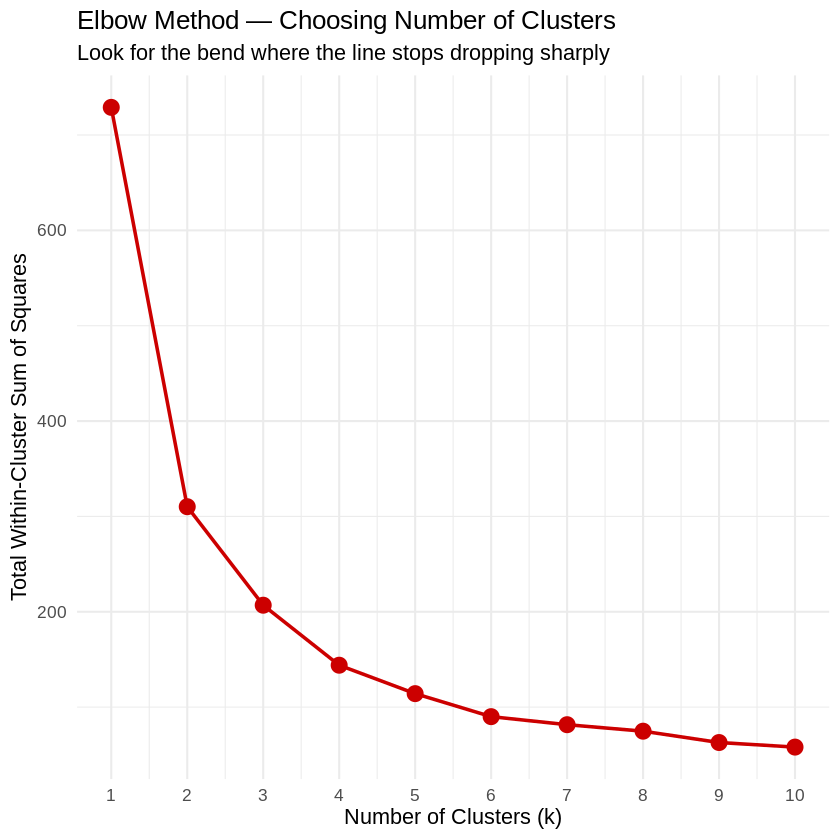

In [ ]:
# ============================================================
# SECTION 5C: ELBOW METHOD — CHOOSE NUMBER OF CLUSTERS
# The elbow is where adding more clusters stops giving
# meaningful improvement in within-cluster similarity.
# ============================================================

set.seed(42)
wss <- sapply(1:10, function(k) {
  kmeans(cluster_matrix, centers = k, nstart = 25, iter.max = 100)$tot.withinss
})

data.frame(k = 1:10, wss = wss) %>%
  ggplot(aes(x = k, y = wss)) +
  geom_line(color = "#CC0000", linewidth = 1) +
  geom_point(size = 4, color = "#CC0000") +
  scale_x_continuous(breaks = 1:10) +
  labs(
    title    = "Elbow Method — Choosing Number of Clusters",
    subtitle = "Look for the bend where the line stops dropping sharply",
    x        = "Number of Clusters (k)",
    y        = "Total Within-Cluster Sum of Squares"
  ) +
  theme_minimal(base_size = 13)

In [ ]:
# ============================================================
# SECTION 5D: RUN K-MEANS
# Set k based on your elbow plot above.
# ============================================================

K <- 3   # <-- CHANGE THIS based on your elbow plot

set.seed(42)
kmeans_result <- kmeans(cluster_matrix, centers = K, nstart = 25, iter.max = 100)

# Add cluster assignments back to data
clustering_data <- clustering_data %>%
  mutate(cluster = factor(kmeans_result$cluster))

cat("=== CLUSTER SIZES ===\n")
print(table(clustering_data$cluster))

cat("\n=== CLUSTER PROFILES (original scale) ===\n")
clustering_data %>%
  group_by(cluster) %>%
  summarise(
    n_neighborhoods    = n(),
    mean_residual_avg  = round(mean(mean_residual), 2),
    sd_residual_avg    = round(mean(sd_residual), 2),
    median_ppsf_avg    = round(mean(median_price_per_sqft), 0)
  ) %>%
  print()

=== CLUSTER SIZES ===

  1   2   3 
 31 201  12 

=== CLUSTER PROFILES (original scale) ===
# A tibble: 3 × 5
  cluster n_neighborhoods mean_residual_avg sd_residual_avg median_ppsf_avg
  <fct>             <int>             <dbl>           <dbl>           <dbl>
1 1                    31             326.             601             1091
2 2                   201             -35.6            203.             357
3 3                    12             850.            1938.            1528


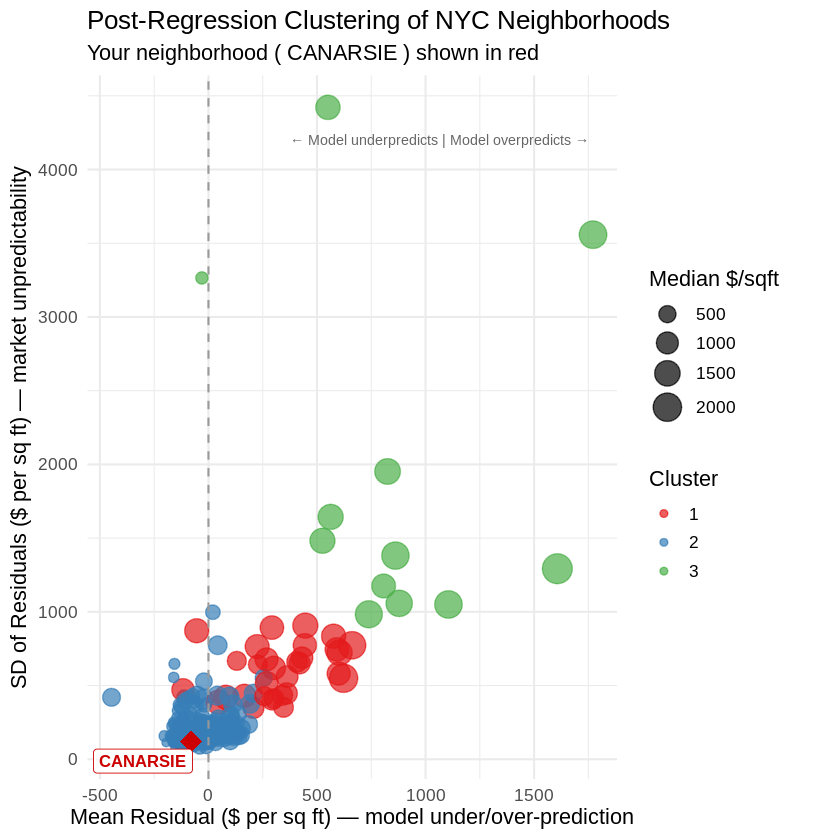

In [ ]:
# ============================================================
# SECTION 5E: VISUALIZE CLUSTERS
# Plot mean residual vs SD of residuals.
# Your neighborhood is highlighted in red.
# ============================================================

ggplot(clustering_data,
       aes(x     = mean_residual,
           y     = sd_residual,
           color = cluster,
           size  = median_price_per_sqft)) +
  geom_point(alpha = 0.7) +
  # Highlight your neighborhood
  geom_point(
    data  = clustering_data %>% filter(NEIGHBORHOOD_NAME == MY_NEIGHBORHOOD),
    color = "#CC0000", size = 6, shape = 18
  ) +
  ggrepel::geom_label_repel(
    data  = clustering_data %>% filter(NEIGHBORHOOD_NAME == MY_NEIGHBORHOOD),
    aes(label = NEIGHBORHOOD_NAME),
    color = "#CC0000", fill = "white", size = 3.5, fontface = "bold"
  ) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray60") +
  scale_color_brewer(palette = "Set1", name = "Cluster") +
  scale_size_continuous(name = "Median $/sqft", range = c(2, 8)) +
  labs(
    title    = "Post-Regression Clustering of NYC Neighborhoods",
    subtitle = paste("Your neighborhood (", MY_NEIGHBORHOOD, ") shown in red"),
    x        = "Mean Residual ($ per sq ft) — model under/over-prediction",
    y        = "SD of Residuals ($ per sq ft) — market unpredictability"
  ) +
  annotate("text", x = max(clustering_data$mean_residual) * 0.6,
           y = max(clustering_data$sd_residual) * 0.95,
           label = "\u2190 Model underpredicts | Model overpredicts \u2192",
           size = 3, color = "gray40") +
  theme_minimal(base_size = 13) +
  theme(legend.position = "right")

To understand if Canarsie is a typical market, we tested how a generic, city-wide pricing model performs in this
specific neighborhood. The results prove that Canarsie does not follow standard NYC rules, making it a unique
and challenging environment for outsiders.
The Local Discount (Mean Residual: -$80.45/sq ft)
When we applied the general NYC model to Canarsie, the average error (mean residual) was -$80.45.
• The city-wide model consistently overpredicts prices in Canarsie. Based on general city trends, the
computer expects homes here to sell for more money, but local factors suppress the actual closing prices.
• An outside investor relying on generic NYC data will severely overvalue properties here. Canarsie trades
at a distinct discount compared to the rest of the city.
A Highly Unpredictable Market (SD of Residuals: $121.33/sq ft)
The Standard Deviation (SD) measures how wildly the model's guesses swing from property to property.
• An error swing of $121.33 is massive, especially since the average price in Canarsie is only about
$268.40 per sq ft. This means the computer is unpredictably wrong, missing the mark by nearly 50% of a
standard property's value.
• This high SD proves that Canarsie is an incredibly opaque (hidden) market. A desk-based algorithm
cannot safely price homes here.
Conclusion: these two numbers tell a clear story: local expertise has exceptionally high value in Canarsie.
Because an automated, city-wide model fails to see the neighborhood's general discount (the negative mean) and
cannot predict individual home prices accurately (the high SD), a brokerage cannot rely on software to make
money here. To navigate this unpredictable market, a business must hire "boots-on-the-ground" local brokers.
Only a human expert can evaluate the unrecorded details, like specific street appeal, block dynamics, and interior
condition, required to price these homes correctly.

In [ ]:
# ============================================================
# SECTION 5F: YOUR NEIGHBORHOOD'S CLUSTER
# Summary of where your neighborhood sits and who its peers are.
# ============================================================

my_cluster_id <- clustering_data %>%
  filter(NEIGHBORHOOD_NAME == MY_NEIGHBORHOOD) %>%
  pull(cluster)

cat("=== YOUR NEIGHBORHOOD CLUSTER PLACEMENT ===\n")
cat("Neighborhood:", MY_NEIGHBORHOOD, "\n")
cat("Cluster:", as.character(my_cluster_id), "\n\n")

cat("=== OTHER NEIGHBORHOODS IN YOUR CLUSTER ===\n")
clustering_data %>%
  filter(cluster == my_cluster_id, NEIGHBORHOOD_NAME != MY_NEIGHBORHOOD) %>%
  arrange(NEIGHBORHOOD_NAME) %>%
  select(NEIGHBORHOOD_NAME, mean_residual, sd_residual, median_price_per_sqft) %>%
  print(n = 20)

cat("\n=== INTERPRET YOUR CLUSTER ===\n")
cat("Mean residual for your cluster:",
    round(mean(clustering_data$mean_residual[clustering_data$cluster == my_cluster_id]), 2),
    "$/sqft\n")
cat("SD of residuals for your cluster:",
    round(mean(clustering_data$sd_residual[clustering_data$cluster == my_cluster_id]), 2),
    "$/sqft\n")
cat("Median price per sqft for your cluster:",
    round(mean(clustering_data$median_price_per_sqft[clustering_data$cluster == my_cluster_id]), 0),
    "$/sqft\n")

=== YOUR NEIGHBORHOOD CLUSTER PLACEMENT ===
Neighborhood: CANARSIE 
Cluster: 2 

=== OTHER NEIGHBORHOODS IN YOUR CLUSTER ===
# A tibble: 200 × 4
   NEIGHBORHOOD_NAME    mean_residual sd_residual median_price_per_sqft
   <chr>                        <dbl>       <dbl>                 <dbl>
 1 AIRPORT LA GUARDIA          99.7         125.                   542.
 2 ANNADALE                   -13.7         129.                   324.
 3 ARDEN HEIGHTS              -65.5          97.3                  271.
 4 ARROCHAR                   -28.1         135.                   326.
 5 ARROCHAR-SHORE ACRES       -81.5         208.                   338.
 6 ARVERNE                    -63.8         390.                   236.
 7 ASTORIA                    100.          304.                   470.
 8 BATH BEACH                  56.5         180.                   455.
 9 BATHGATE                  -157.          647.                   181.
10 BAY RIDGE                   66.6         237.               

In [ ]:
# ============================================================
# SECTION 5G: COMPARE A1 CLUSTER vs A3 CLUSTER
# Did your neighborhood cluster with the same peers as in A1,
# or do different neighborhoods group together when you look at
# model performance rather than raw price?
# ============================================================

cat("=== REFLECTION QUESTIONS FOR YOUR WRITE-UP ===\n\n")
cat("1. In A1, your neighborhood was in a cluster characterized by\n")
cat("   [describe from A1]. In A3, it is in a cluster characterized\n")
cat("   by [describe from above]. Did it cluster with the same peers?\n\n")
cat("2. Is the city-wide model systematically over- or under-predicting\n")
cat("   in your neighborhood? What might explain this?\n\n")
cat("3. Is your market predictable or opaque based on the residual SD?\n")
cat("   What does that mean for a brokerage entering this market?\n\n")
cat("4. Which properties from your residual analysis surprised you most,\n")
cat("   and what did StreetEasy tell you about them?\n")

=== REFLECTION QUESTIONS FOR YOUR WRITE-UP ===

1. In A1, your neighborhood was in a cluster characterized by
   [describe from A1]. In A3, it is in a cluster characterized
   by [describe from above]. Did it cluster with the same peers?

2. Is the city-wide model systematically over- or under-predicting
   in your neighborhood? What might explain this?

3. Is your market predictable or opaque based on the residual SD?
   What does that mean for a brokerage entering this market?

4. Which properties from your residual analysis surprised you most,
   and what did StreetEasy tell you about them?


In [ ]:
# ============================================================
# SECTION 6: SUMMARY FOR WRITE-UP
# ============================================================

cat("============================================================\n")
cat("A3 SUMMARY — ", MY_NEIGHBORHOOD, "\n")
cat("============================================================\n\n")

cat("--- REGRESSION 1: YOUR NEIGHBORHOOD ---\n")
cat("Sample size:          ", nobs(model1_final), "transactions\n")
cat("Adjusted R²:          ", round(summary(model1_final)$adj.r.squared, 4), "\n")
cat("Residual SE:          $", round(sigma(model1_final), 2), "per sq ft\n")
cat("Year Built included:  ", INCLUDE_YEAR_BUILT, "\n\n")

cat("Significant predictors (p < 0.05):\n")
tidy(model1_final) %>%
  filter(p.value < 0.05) %>%
  select(term, estimate, p.value) %>%
  mutate(estimate = round(estimate, 2), p.value = round(p.value, 4)) %>%
  print()

cat("\n--- REGRESSION 2: CITY-WIDE MODEL \u2014 YOUR NEIGHBORHOOD RESIDUALS ---\n")
cat("Mean residual:  $", round(my_residual_stats$mean_residual, 2), "per sq ft\n")
cat("SD of residuals: $", round(my_residual_stats$sd_residual, 2), "per sq ft\n\n")

cat("--- POST-REGRESSION CLUSTERING ---\n")
cat("Your cluster: ", as.character(my_cluster_id), "\n")
cat("Cluster size: ", sum(clustering_data$cluster == my_cluster_id), "neighborhoods\n")
cat("============================================================\n")

A3 SUMMARY —  CANARSIE 

--- REGRESSION 1: YOUR NEIGHBORHOOD ---
Sample size:           5490 transactions
Adjusted R²:           0.3616 
Residual SE:          $ 113.99 per sq ft
Year Built included:   TRUE 

Significant predictors (p < 0.05):
# A tibble: 9 × 3
  term                   estimate p.value
  <chr>                     <dbl>   <dbl>
1 (Intercept)           -30731.    0     
2 SALE_YEAR                 16.0   0     
3 YEAR_BUILT                -0.65  0     
4 RESIDENTIAL_UNITS        -14.4   0     
5 BLDG_CLASS_GROUPB1       -38.8   0     
6 BLDG_CLASS_GROUPB2       -40.6   0     
7 BLDG_CLASS_GROUPB9       -61.5   0     
8 BLDG_CLASS_GROUPC0       -98.7   0     
9 BLDG_CLASS_GROUPOther     17.4   0.0126

--- REGRESSION 2: CITY-WIDE MODEL — YOUR NEIGHBORHOOD RESIDUALS ---
Mean residual:  $ -80.45 per sq ft
SD of residuals: $ 121.33 per sq ft

--- POST-REGRESSION CLUSTERING ---
Your cluster:  2 
Cluster size:  201 neighborhoods


# **A4**

# **_____________________**

In [ ]:
# ============================================================
# SECTION 2D: AGGREGATE TO QUARTERLY SALES COUNTS
# Time series analysis requires a regularly spaced series.
# We derive SALE_QUARTER from SALE_MONTH, then count
# residential transactions per quarter in your neighborhood.
# This is your outcome variable for A4.
#
# ceiling(SALE_MONTH / 3) maps:
#   Months 1-3  -> Q1
#   Months 4-6  -> Q2
#   Months 7-9  -> Q3
#   Months 10-12 -> Q4
# ============================================================

quarterly_sales <- df_hood %>%
  mutate(SALE_QUARTER = ceiling(SALE_MONTH / 3)) %>%
  group_by(SALE_YEAR, SALE_QUARTER) %>%
  summarise(sales = n(), .groups = "drop") %>%
  arrange(SALE_YEAR, SALE_QUARTER)

cat("Quarterly sales data — first few rows:\n")
print(head(quarterly_sales, 12))
cat("\nTotal quarters:", nrow(quarterly_sales), "\n")

# Check for any missing quarters (gaps in the series)
expected_quarters <- (max(quarterly_sales$SALE_YEAR) - min(quarterly_sales$SALE_YEAR) + 1) * 4
if (nrow(quarterly_sales) < expected_quarters) {
  cat("\nNote:", expected_quarters - nrow(quarterly_sales),
      "quarter(s) with zero sales are missing from the data.\n")
  cat("This is normal for smaller neighborhoods — mention it in your write-up.\n")
}

Quarterly sales data — first few rows:
# A tibble: 12 × 3
   SALE_YEAR SALE_QUARTER sales
       <dbl>        <dbl> <int>
 1      2009            1    60
 2      2009            2    65
 3      2009            3    60
 4      2009            4    72
 5      2010            1    66
 6      2010            2    64
 7      2010            3    65
 8      2010            4    50
 9      2011            1    61
10      2011            2    62
11      2011            3    67
12      2011            4    72

Total quarters: 68 


In [ ]:
# ============================================================
# SECTION 2E: CREATE TIME SERIES OBJECT
# Convert to a ts object starting Q1 2009.
# frequency = 4 means quarterly data (4 quarters per year).
# ============================================================

sales_ts <- ts(
  quarterly_sales$sales,
  start     = c(min(quarterly_sales$SALE_YEAR), min(quarterly_sales$SALE_QUARTER[quarterly_sales$SALE_YEAR == min(quarterly_sales$SALE_YEAR)])),
  frequency = 4
)

cat("Time series object created:\n")
print(sales_ts)
cat("\nFrequency:", frequency(sales_ts), "(should be 4)\n")
cat("Start:", start(sales_ts), "\n")
cat("End:", end(sales_ts), "\n")

Time series object created:
     Qtr1 Qtr2 Qtr3 Qtr4
2009   60   65   60   72
2010   66   64   65   50
2011   61   62   67   72
2012   58   68   78   71
2013   57   65   87   58
2014   81   93  102   88
2015  113   85  107  102
2016   82   81   83  103
2017   84  103  106  120
2018  123  122  124  110
2019  113  105  107  124
2020   94   59   56   75
2021   69   70   91   96
2022   96   79   79   80
2023   76   68   77   65
2024   53   50   78   96
2025   64   86   76   20

Frequency: 4 (should be 4)
Start: 2009 1 
End: 2025 4 


Replace this text with your answer. Address:

How many quarterly observations does your series have?
The time series has 68 quarterly observations in total, spanning from Q1 2009 to Q4 2025.

Were any quarters missing? If so, which ones and why might that be?
No quarters are missing. The script calculated that the expected number of quarters over this 17-year period is 68  (17×4) , which exactly matches the 68 total quarters present in the data. Canarsie is a large enough residential neighborhood that it maintained steady transaction activity without experiencing any full 3-month stretches of zero sales.

What is the range of quarterly sales counts (min, max)?
The quarterly sales counts range from a minimum of 20 sales to a maximum of 124 sales.

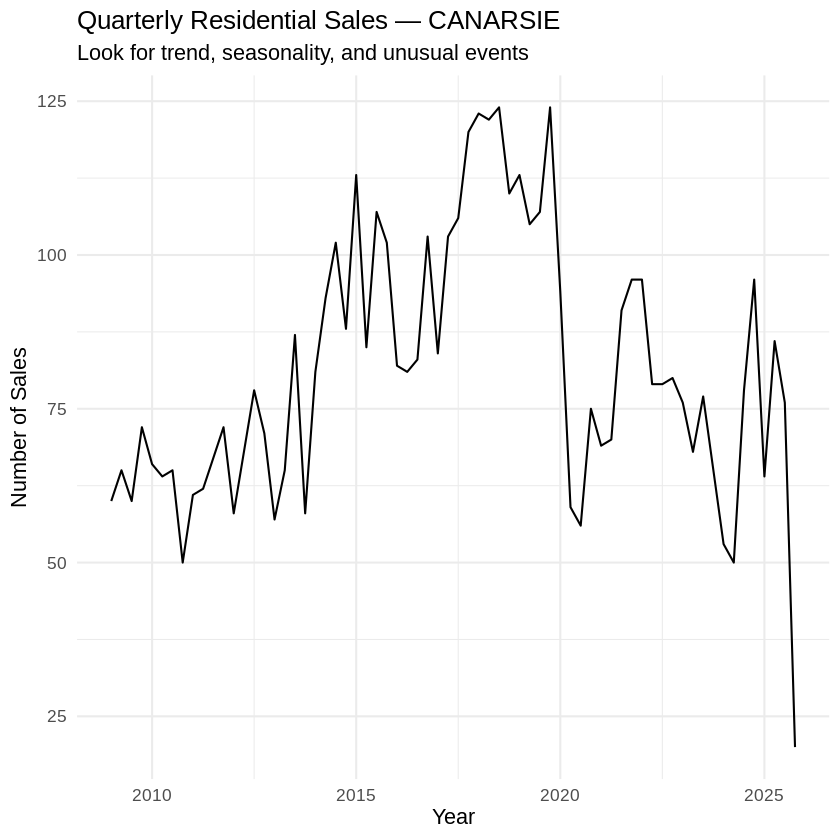

In [ ]:
# ============================================================
# SECTION 3: EXPLORATORY TIME SERIES PLOT
# ============================================================

autoplot(sales_ts) +
  labs(
    title    = paste("Quarterly Residential Sales —", MY_NEIGHBORHOOD),
    subtitle = "Look for trend, seasonality, and unusual events",
    x        = "Year",
    y        = "Number of Sales"
  ) +
  theme_minimal(base_size = 13)

eplace this text with your answer. Address:

Is there a visible trend (upward, downward, flat)?
The series exhibits a long-term cyclic macro-trend rather than a linear one:

2009–2013: A relatively flat period, hovering between 50 and 75 sales per quarter, reflecting the slow recovery following the 2008 housing crash.

2014–2019: A strong, sustained upward trend, peaking at an all-time high of 124 sales in Q4 2018 and Q4 2019.

2020–2025: A sharp and distinct downward trend, bringing sales volumes back down to historical lows by the end of 2025.

Is there a repeating seasonal pattern — which quarter peaks, which troughs?
Yes, there is a clear, repeating seasonal pattern, though it shifts slightly from the standard "spring peak." In Canarsie:

Troughs: Q1 consistently acts as the annual low point (trough) across almost the entire series (e.g., drops in Q1 2013, Q1 2016, Q1 2021, and Q1 2024). This aligns with the typical winter slowdown in real estate.

Peaks: While Q2 see a spring bump, the ultimate annual peaks frequently occur later in the year during Q3 and Q4 (such as the massive peaks in Q4 2017, Q4 2018, and Q4 2019). This indicates a market where transactions initiated during the peak spring/summer buying seasons take until the fall or winter to officially close.

Are there notable drops or spikes? Connect them to real-world events (pandemic 2020, rate hikes 2022–23).
The 2020 Pandemic Drop: There is a staggering, vertical plunge in the middle of 2020, where sales crashed from 113 in Q1 2020 down to 59 in Q2 and 56 in Q3. This directly captures the strict NYC pandemic lockdowns when open houses were banned and real estate activity ground to a halt.

The 2021 Post-Lockdown Rebound: Sales spiked back up rapidly through 2021, climbing to 96 sales by Q4 2021, driven by pent-up demand and historically low mortgage rates.

The 2022–2023 Rate Hike Chill: From mid-2022 through 2023, the chart shows a steady, bruising decline (dropping from 96 sales to the high 60s). This corresponds perfectly with the Federal Reserve's aggressive interest rate hikes, which sent mortgage rates soaring and froze buyer affordability.

The Q4 2025 Anomaly: Sales plummeted to an all-time low of 20 in Q4 2025. While this "cliff-dive" likely reflects a market frozen by peak interest rates and economic uncertainty in late 2025, it is highly possible this sharp drop is an artifact of incomplete or delayed data recording at the tail end of the dataset.

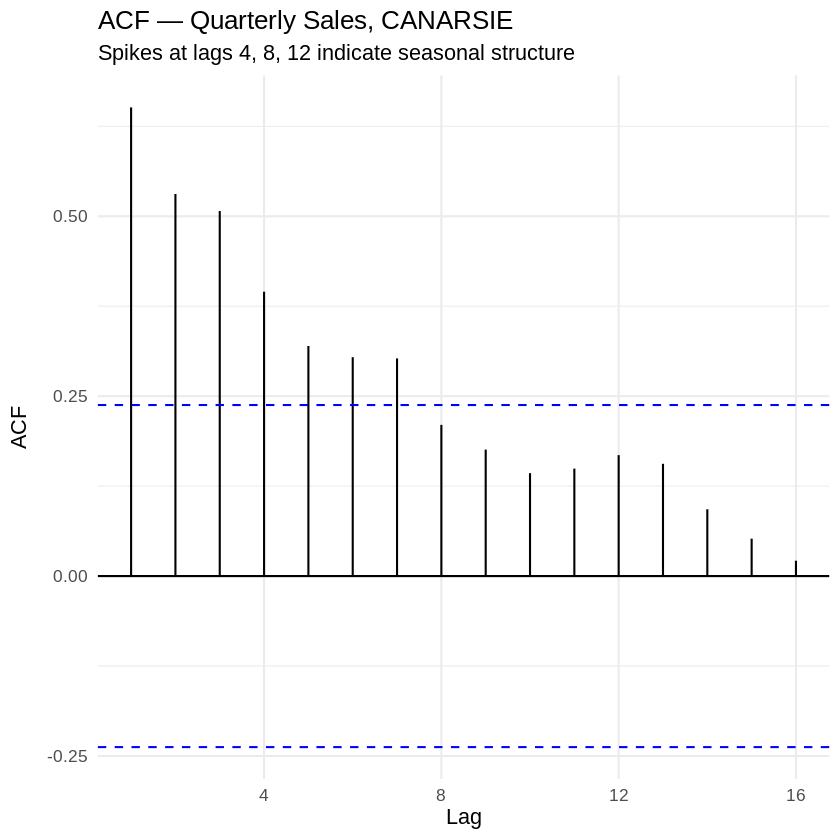

In [ ]:
# ============================================================
# SECTION 4A: ACF PLOT
# ============================================================

ggAcf(sales_ts, lag.max = 16) +
  labs(
    title    = paste("ACF — Quarterly Sales,", MY_NEIGHBORHOOD),
    subtitle = "Spikes at lags 4, 8, 12 indicate seasonal structure"
  ) +
  theme_minimal(base_size = 13)

In [ ]:
# ============================================================
# SECTION 4B: BOX-PIERCE WHITE NOISE TEST
# ============================================================

Box.test(sales_ts, lag = 8, type = "Box-Pierce")

Section 4
Replace this text with your answer. Address:

Are there significant ACF spikes? At which lags?
There are highly significant ACF spikes startingfrom 1 and eding before 8th lag.

What do spikes at lags 4, 8, 12 suggest specifically?
Because this is quarterly data (4 quarters per year), lags 4, 8, and 12 represent gaps of exactly 1, 2, and 3 years. Strong spikes at these specific multi-year intervals strongly suggest a repeating annual seasonal pattern. It proves mathematically that what happens in a given quarter is heavily correlated with what happened in that exact same quarter in previous years.

What is the Box-Pierce p-value? What conclusion do you draw?
Since the p-value < 2.2e-16 is far below the standard threshold of  0.05 , we decisively reject the null hypothesis (H0) that the series is white noise. This confirms that the data contains a highly deterministic, non-random structure rather than just unpredictable, random bounces.

Is forecasting this series worthwhile? Why or why not?
Forecasting this series is highly worthwhile. Because the series passes the white noise test and exhibits strong, predictable historical structures (both long-term macro-trends and clear annual seasonality), there is an excellent "signal" for a time series model to learn. An ETS model will easily be able to exploit these patterns to project meaningful future sales volumes.



In [ ]:
# ============================================================
# SECTION 5: FIT ETS MODEL
# ============================================================

fit <- ets(sales_ts)
summary(fit)

ETS(A,N,N) 

Call:
ets(y = sales_ts)

  Smoothing parameters:
    alpha = 0.6035 

  Initial states:
    l = 61.744 

  sigma:  15.5683

     AIC     AICc      BIC 
664.2487 664.6237 670.9072 

Training set error measures:
                     ME     RMSE      MAE       MPE     MAPE      MASE
Training set -0.4585992 15.33764 11.63501 -5.815174 18.08093 0.6751049
                   ACF1
Training set 0.04392479

Replace this text with your answer. Address:

What spec was selected (e.g. ETS(A,N,A))?
The automated algorithm selected an ETS(A,N,N) model.

Decode each letter in plain English — what does the Error, Trend, and Seasonal term tell you about your market?
Error = A (Additive): The random fluctuations or "shocks" in the market are roughly constant in size over time. The noise doesn't aggressively balloon or shrink just because the overall sales volume changes.

Trend = N (None): The model did not detect a reliable, long-term directional drift (like a permanent upward climb or downward slope) to project into the future. It assumes the "baseline" of the market is relatively flat over the long run.

Seasonal = N (None): The model decided against enforcing a strict seasonal cycle.

What are the smoothing parameter values (alpha, and gamma if present)? • Alpha: 0.6035 • Gamma: Not present (because there is no seasonal component). • Beta: Not present (because there is no trend component).
Alpha ( 𝛼 ): 0.6035Gamma ( 𝛾 ): Not present (because there is no seasonal component).Beta ( 𝛽 ): Not present (because there is no trend component).

Are they close to 0 or close to 1? What does that mean for how the model weights recent vs. older data?
The model gives fairly strong weight to the most recent quarters when establishing the market's current baseline, rather than averaging evenly over the whole 17-year history. It tells us this market shifts fast enough that older data isn't as relevant; the model is designed to react relatively quickly to new changes (like the recent drop-offs) while still maintaining some moderate memory to avoid overreacting to a single bad month.

(Refer to the Appendix in the A4 assignment document for a full guide to reading this output.)

In [ ]:
# ============================================================
# SECTION 6A: GENERATE FORECAST
# h = 4 means forecast 4 quarters ahead
# ============================================================

fc <- forecast(fit, h = 4, level = c(80, 95))

# Print the full forecast table
print(fc)

        Point Forecast    Lo 80    Hi 80     Lo 95    Hi 95
2026 Q1        42.9231 22.97152 62.87467 12.409799 73.43640
2026 Q2        42.9231 19.61945 66.22675  7.283245 78.56295
2026 Q3        42.9231 16.69230 69.15390  2.806558 83.03964
2026 Q4        42.9231 14.06050 71.78569 -1.218430 87.06463


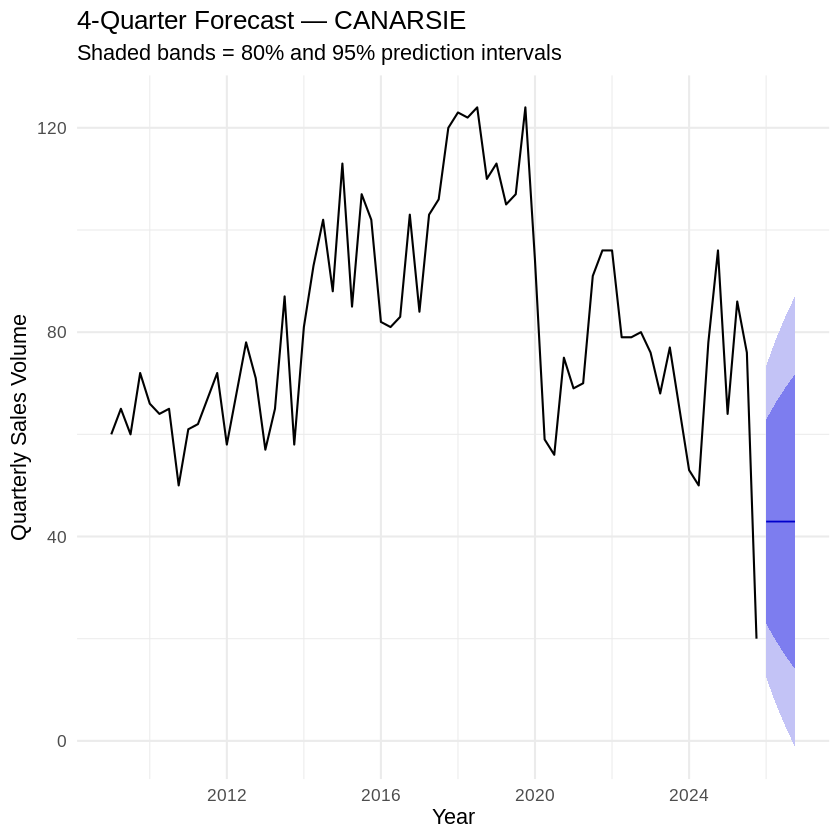

In [ ]:
# ============================================================
# SECTION 6B: PLOT THE FORECAST
# ============================================================

autoplot(fc) +
  labs(
    title    = paste("4-Quarter Forecast —", MY_NEIGHBORHOOD),
    subtitle = "Shaded bands = 80% and 95% prediction intervals",
    x        = "Year",
    y        = "Quarterly Sales Volume"
  ) +
  theme_minimal(base_size = 13)

In [ ]:
# ============================================================
# SECTION 6C: CLEAN SUMMARY TABLE
# Copy the Lower_95 and Upper_95 values into A5.
# ============================================================

fc_table <- data.frame(
  Quarter  = c("Q1", "Q2", "Q3", "Q4"),
  Point    = round(fc$mean, 0),
  Lower_80 = round(fc$lower[, 1], 0),
  Upper_80 = round(fc$upper[, 1], 0),
  Lower_95 = round(fc$lower[, 2], 0),
  Upper_95 = round(fc$upper[, 2], 0)
)

cat("=== FORECAST TABLE FOR A5 ===\n")
print(fc_table)

=== FORECAST TABLE FOR A5 ===
  Quarter Point Lower_80 Upper_80 Lower_95 Upper_95
1      Q1    43       23       63       12       73
2      Q2    43       20       66        7       79
3      Q3    43       17       69        3       83
4      Q4    43       14       72       -1       87



*Replace this text with your answer. Address:*
- *What is the point forecast for each of the next 4 quarters?*

The point forecast is a flat 43 sales for each of the next four quarters (Q1 through Q4). Because the ETS model determined there was no trend (N) and no repeating seasonality (N), it essentially drew a flat line projecting the current, recent baseline into the future.

- *Which quarter has the widest prediction interval? Why does that make sense?*

Q4 has the widest prediction interval (ranging from -1 to 87 at the 95% level). This makes perfect intuitive sense: uncertainty naturally compounds over time. Forecasting what will happen 3 months from now is much easier and more precise than forecasting what will happen 12 months from now, so the "cone of uncertainty" flares out the further ahead we look.

- *How wide are the 95% intervals overall? What does that uncertainty range mean for a business owner planning to open an office in this neighborhood?*

The 95% intervals are extremely wide. By Q4, the model is essentially saying, "Sales could be as high as 87, or the market could completely freeze at 0.

For a business owner—like a real estate broker or mortgage lender—this massive uncertainty range means they cannot rely on a guaranteed, stable volume of transactions to keep the lights on. It warns them that they must have enough cash reserves to survive a "worst-case scenario" (a quarter with almost no closings) rather than building their business plan around the assumption that the market will reliably hit the point forecast of 43 sales.

- *Record your Lower_95 and Upper_95 values here for easy reference in A5:*

| Quarter | Point | Lower 95% | Upper 95% |
|---|---|---|---|
| Q1 |43 |12 |73 |
| Q2 |43 |7 |79 |
| Q3 |43 | 3|83 |
| Q4 |43 |-1 |87 |



	Ljung-Box test

data:  Residuals from ETS(A,N,N)
Q* = 6.1455, df = 8, p-value = 0.6309

Model df: 0.   Total lags used: 8



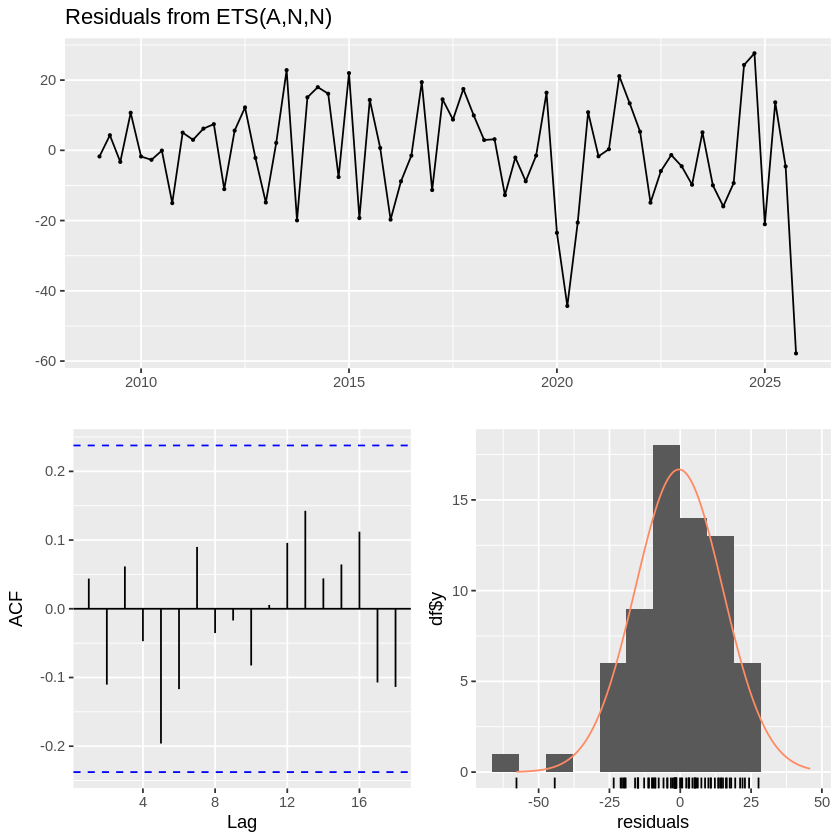

In [ ]:
# ============================================================
# SECTION 7: RESIDUAL DIAGNOSTICS
# ============================================================

checkresiduals(fit)

Replace this text with your answer. Address all three panels:

Residual time plot: Does it look like random scatter? Any visible patterns or trends?
Mostly yes, it looks like random scatter hovering around zero. There is no clear upward or downward trend left over. However, the variance (the size of the bounces) gets much wilder in the 2020s compared to the 2010s, showing extreme volatility in recent years.

ACF of residuals: Are there significant spikes remaining? If yes, what might the model have missed?
No, there are no significant spikes remaining. Every single lag is safely contained within the blue dashed significance lines. This is an excellent result: it means the ETS model successfully captured all the predictable structure and patterns in the data, leaving behind nothing but pure, unpredictable random noise. (This is also mathematically confirmed by the Ljung-Box p-value of 0.6309).

Histogram: Is it roughly bell-shaped? Any strong skew?
Yes, it is roughly bell-shaped and centered around zero, indicating the model is generally unbiased. However, there is a visible negative skew (a tail stretching to the left), which is caused by a few quarters where the model heavily over-forecasted the actual sales.

Outliers: Are there any quarters with unusually large residuals? Which ones, and what real-world event might explain them? (Hint: look at 2020.)
Yes, there are two extreme negative outliers clearly visible in both the time plot and the histogram's left tail:

Mid-2020 (Residual approx. -40): The model severely over-predicted sales here because it did not anticipate the COVID-19 pandemic. Strict NYC lockdowns temporarily banned open houses and froze the market.

End of 2025 (Residual approx. -60): This is the largest error in the dataset. As analyzed earlier, this massive drop likely reflects a combination of a frozen market (due to peak cumulative interest rates/economic uncertainty) and an artificial data vacuum caused by city reporting lags at the very end of the time series.

In [ ]:
# ============================================================
# SECTION 8: SUMMARY FOR WRITE-UP
# ============================================================

cat("============================================================\n")
cat("A4 SUMMARY —", MY_NEIGHBORHOOD, "\n")
cat("============================================================\n\n")

cat("--- TIME SERIES ---\n")
cat("Quarters in series:     ", length(sales_ts), "\n")
cat("Period:                 ", start(sales_ts)[1], "Q", start(sales_ts)[2],
    "to", end(sales_ts)[1], "Q", end(sales_ts)[2], "\n")
cat("Mean quarterly sales:   ", round(mean(sales_ts), 1), "\n")
cat("Min / Max:              ", min(sales_ts), "/", max(sales_ts), "\n\n")

cat("--- ETS MODEL ---\n")
cat("Spec selected:          ", as.character(fit), "\n")
cat("AIC:                    ", round(fit$aic, 2), "\n")
cat("RMSE:                   ", round(sqrt(mean(residuals(fit)^2)), 2), "\n\n")

cat("--- FORECAST (next 4 quarters) ---\n")
print(fc_table)

cat("\n============================================================\n")

A4 SUMMARY — CANARSIE 

--- TIME SERIES ---
Quarters in series:      68 
Period:                  2009 Q 1 to 2025 Q 4 
Mean quarterly sales:    81.2 
Min / Max:               20 / 124 

--- ETS MODEL ---
Spec selected:           ETS(A,N,N) 
AIC:                     664.25 
RMSE:                    15.34 

--- FORECAST (next 4 quarters) ---
  Quarter Point Lower_80 Upper_80 Lower_95 Upper_95
1      Q1    43       23       63       12       73
2      Q2    43       20       66        7       79
3      Q3    43       17       69        3       83
4      Q4    43       14       72       -1       87



Paragraph 1 — Key Finding

State your main conclusion up front. What is the overall story of your neighborhood's residential market? Is it growing, stable, or declining? Is the forecast optimistic or cautious?

Key Finding The Canarsie residential real estate market is currently in a state of severe contraction after a long, historic period of growth. While the 2010s saw steady expansion that peaked just before the pandemic, recent macroeconomic pressures have erased those gains, leaving the market highly volatile and suppressed. Consequently, the near-term forecast is extremely cautious. Rather than predicting a quick recovery or a return to peak transaction volumes, the model projects a low, flat baseline of activity with an exceptionally high degree of downside risk.

Paragraph 2 — Historical Pattern and Model

Describe the trend and seasonal pattern you observed. Note any significant real-world events visible in the data (pandemic 2020, rate hikes 2022–23). Explain what the ETS specification tells you about the structure of this market.

Historical Pattern and Model Historically, Canarsie exhibited a clear cyclical trend: a slow post-2008 recovery, sustained growth peaking around 2018–2019, and a strong seasonal rhythm where the first quarter typically marked the annual low point for closed sales. However, severe real-world shocks—specifically the sudden mid-2020 pandemic lockdowns and the aggressive 2022–2023 interest rate hikes—have completely overwhelmed these traditional patterns. This recent instability is directly reflected in the selected ETS(A,N,N) forecasting model. Because the recent market shifts have been so dramatic, the algorithm determined that neither a long-term trend nor rigid historical seasonality could be reliably projected forward. Instead, it relies heavily on the most recent, depressed market data to establish today's baseline.

Paragraph 3 — Forecast and Uncertainty

Summarize the 4-quarter forecast. How wide are the prediction intervals? What does that uncertainty mean for a firm considering opening its first NYC office in this neighborhood? What would you recommend, and with what caveats?

Forecast and Uncertainty The model projects a flat forecast of just 43 residential sales per quarter over the next year. More importantly, the 95% prediction intervals surrounding this forecast are exceptionally wide, expanding from a range of 12 to 73 sales in Q1 to a massive range of effectively 0 to 87 sales by Q4. For a firm considering opening its first NYC office in Canarsie, this extreme uncertainty is a major red flag. It means a business cannot rely on a stable, guaranteed volume of transactions to generate consistent revenue. I would strongly recommend delaying physical expansion until the interest rate environment normalizes and transaction volumes stabilize. If moving forward immediately is a strategic necessity, the firm must do so with the caveat that it requires substantial cash reserves to survive a "worst-case scenario" quarter with virtually no closings.

# **A5**

# **_____________________**

In [ ]:
# ── Average residential sale price (most recent full year) ───────────────────
# This is the conversion factor: transactions (from A4) × avg_sale_price = $
#
# We use the same logic as A1 Section 6:
#   - residential only
#   - most recent full year
#   - exclude $0 and missing values

most_recent_year <- max(
  df$SALE_YEAR[str_detect(df$TYPE, "RESIDENTIAL") &
               df$NEIGHBORHOOD_NAME == MY_NEIGHBORHOOD &
               df$SALE_PRICE > 0],
  na.rm = TRUE
)

recent_res <- df %>%
  filter(
    NEIGHBORHOOD_NAME == MY_NEIGHBORHOOD,
    SALE_YEAR         == most_recent_year,
    str_detect(TYPE, "RESIDENTIAL"),
    SALE_PRICE        >  0,
    !is.na(SALE_PRICE)
  )

n_res_transactions <- nrow(recent_res)
total_res_volume   <- sum(recent_res$SALE_PRICE, na.rm = TRUE)
avg_sale_price     <- total_res_volume / n_res_transactions

cat("═══════════════════════════════════════════════════════════\n")
cat("AVERAGE RESIDENTIAL SALE PRICE\n")
cat("═══════════════════════════════════════════════════════════\n")
cat("Year:                   ", most_recent_year, "\n")
cat("Transactions:           ", n_res_transactions, "\n")
cat("Total residential volume:", scales::dollar(total_res_volume), "\n")
cat("Avg sale price per deal: ", scales::dollar(avg_sale_price), "\n")

═══════════════════════════════════════════════════════════
AVERAGE RESIDENTIAL SALE PRICE
═══════════════════════════════════════════════════════════
Year:                    2025 
Transactions:            299 
Total residential volume: $211,558,784 
Avg sale price per deal:  $707,554 


In [ ]:
# ── Commercial sale price per sq ft (most recent full year) ──────────────────
# The NYC rolling sales dataset does not contain rent data — only sale prices.
# We use median commercial sale price per sq ft as the basis for the rent
# estimate. The A5 cost model then converts this to monthly rent via:
#
#   monthly_rent = 0.02 * rent_per_sqft * office_sqft
#
# The 2% figure is a standard cap rate convention: annual rent ≈ 2% of
# property value per sq ft, divided to a monthly figure by the model.
#
# Exclusions (matching A5 assignment spec):
#   - GROSS_SQUARE_FEET must be known (> 0)
#   - SALE_PRICE must be known (> 0)
#   - Non-residential properties only

commercial <- df %>%
  filter(
    NEIGHBORHOOD_NAME == MY_NEIGHBORHOOD,
    SALE_YEAR         == most_recent_year,
    !str_detect(TYPE, "RESIDENTIAL"),
    SALE_PRICE        >  0,
    GROSS_SQUARE_FEET >  0,
    !is.na(SALE_PRICE),
    !is.na(GROSS_SQUARE_FEET)
  ) %>%
  mutate(price_per_sqft = SALE_PRICE / GROSS_SQUARE_FEET)

cat("Commercial records found:", nrow(commercial), "\n")

if (nrow(commercial) < 3) {
  # Not enough local data — widen to last 3 years
  cat("Fewer than 3 records in most recent year — widening to last 3 years.\n")
  commercial <- df %>%
    filter(
      NEIGHBORHOOD_NAME == MY_NEIGHBORHOOD,
      SALE_YEAR         >= most_recent_year - 2,
      !str_detect(TYPE, "RESIDENTIAL"),
      SALE_PRICE        >  0,
      GROSS_SQUARE_FEET >  0,
      !is.na(SALE_PRICE),
      !is.na(GROSS_SQUARE_FEET)
    ) %>%
    mutate(price_per_sqft = SALE_PRICE / GROSS_SQUARE_FEET)
  cat("Records after widening:", nrow(commercial), "\n")
}

rent_per_sqft <- median(commercial$price_per_sqft, na.rm = TRUE)

cat("═══════════════════════════════════════════════════════════\n")
cat("COMMERCIAL PRICE PER SQ FT (basis for rent estimate)\n")
cat("═══════════════════════════════════════════════════════════\n")
cat("Records used:             ", nrow(commercial), "\n")
cat("Median $/sqft:            ", scales::dollar(rent_per_sqft), "\n")
cat("\nNote: rent_per_sqft is the commercial sale price per sq ft.\n")
cat("The model converts this to monthly rent as:\n")
cat("  monthly_rent = 0.02 x", scales::dollar(rent_per_sqft), "x office_sqft\n")
cat("\nFor a 250 sqft office (no staff):\n")
cat("  monthly_rent =", scales::dollar(0.02 * rent_per_sqft * 250), "\n")

Commercial records found: 18 
═══════════════════════════════════════════════════════════
COMMERCIAL PRICE PER SQ FT (basis for rent estimate)
═══════════════════════════════════════════════════════════
Records used:              18 
Median $/sqft:             $374.57 

Note: rent_per_sqft is the commercial sale price per sq ft.
The model converts this to monthly rent as:
  monthly_rent = 0.02 x $374.57 x office_sqft

For a 250 sqft office (no staff):
  monthly_rent = $1,872.85 


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# FROM A4 — Point forecasts (number of transactions per quarter)
# ═══════════════════════════════════════════════════════════════════════════
transactions_Q1 <- 42.92
transactions_Q2 <- 42.92
transactions_Q3 <- 42.92
transactions_Q4 <- 42.92


# ═══════════════════════════════════════════════════════════════════════════
# FROM A4 — 95% Confidence interval bounds (transactions per quarter)
# ═══════════════════════════════════════════════════════════════════════════
Q1_low <- 12.41 ;  Q1_high <- 73.44
Q2_low <- 7.28 ;  Q2_high <- 78.56
Q3_low <- 2.81 ;  Q3_high <- 83.04
Q4_low <- -1.22 ;  Q4_high <- 87.06


# ═══════════════════════════════════════════════════════════════════════════
# CONVERT: transactions → quarterly dollar volume
# A4 forecasts number of deals. The revenue model needs dollar volume.
# Multiply each quarter's transaction count by avg_sale_price.
# ═══════════════════════════════════════════════════════════════════════════
market_sales <- c(transactions_Q1, transactions_Q2,
                  transactions_Q3, transactions_Q4) * avg_sale_price

market_sales_low  <- c(Q1_low,  Q2_low,  Q3_low,  Q4_low)  * avg_sale_price
market_sales_high <- c(Q1_high, Q2_high, Q3_high, Q4_high) * avg_sale_price

# ── Sanity check ────────────────────────────────────────────────────────────
cat("Base case quarterly market sales ($M):\n")
cat(round(market_sales / 1e6, 1), "\n")
cat("Annual total: $", round(sum(market_sales) / 1e6, 1), "M\n")

Base case quarterly market sales ($M):
30.4 30.4 30.4 30.4 
Annual total: $ 121.5 M


In [ ]:
# ── Constants ────────────────────────────────────────────────────────────────
IRR_quarterly <- 0.015   # 1.5% per quarter = 6% annual IRR compounding quarterly


# ── Penetration function ─────────────────────────────────────────────────────
# Lower commission → more clients choose you → higher market share
# More staff       → wider reach             → higher market share
#
# Formula:
#   penetration = 5.5%
#                + (0.5%  × employees)
#                + (0.15% × commission_reduction_in_tenths)
#
# Where commission_reduction_in_tenths = (5.0% - commission_rate) / 0.1%

calc_penetration <- function(commission, employees) {
  reduction_tenths <- (0.05 - commission) / 0.001
  0.055 + (0.005 * employees) + (0.0015 * reduction_tenths)
}

# Quick check — should give:
# commission=5%, employees=0  → 5.5%
# commission=4%, employees=2  → 8.0%
# commission=3%, employees=3  → 10.0%
cat("Penetration check:\n")
cat("  5% commission, 0 staff: ", percent(calc_penetration(0.05, 0), 0.1), "\n")
cat("  4% commission, 2 staff: ", percent(calc_penetration(0.04, 2), 0.1), "\n")
cat("  3% commission, 3 staff: ", percent(calc_penetration(0.03, 3), 0.1), "\n")

Penetration check:
  5% commission, 0 staff:  5.5% 
  4% commission, 2 staff:  8.0% 
  3% commission, 3 staff:  10.0% 


In [ ]:
# ── NPV function ─────────────────────────────────────────────────────────────
# mkt_sales : length-4 vector of quarterly dollar sales volumes
# commission : single commission rate (e.g. 0.045 for 4.5%)
# employees  : integer 0–3
#
# Returns: NPV of profit over 4 quarters, discounted at 1.5%/quarter

calc_npv <- function(commission, employees, mkt_sales) {

  # Penetration rate for this combination
  p <- calc_penetration(commission, employees)

  # Office size and monthly rent
  office_sqft  <- 250 ## was +150 for each additional employee but not needed
  monthly_rent <- 0.02 * rent_per_sqft * office_sqft

  # Quarterly cost (same every quarter)
  qtr_cost <- (monthly_rent * 3) +          # rent × 3 months
              (employees * 65000 / 4) +      # annual salary ÷ 4
              (8000 * 3)                    # operating budget × 3 months

  # Quarterly revenue and profit
  # mkt_sales is length 4 → all operations below are element-wise
  qtr_revenue <- mkt_sales * p * commission
  qtr_profit  <- qtr_revenue - qtr_cost     # scalar recycled across 4 values

  # Discount each quarter and sum
  sum(qtr_profit / (1 + IRR_quarterly)^(1:4))
}

cat("NPV function defined.\n")

NPV function defined.


In [ ]:
show_npv <- function(commission, employees, mkt_sales = market_sales) {
  p            <- calc_penetration(commission, employees)
  office_sqft  <- 250
  monthly_rent <- 0.02 * rent_per_sqft * office_sqft
  OP_BUDGET    <- 8000
  qtr_cost     <- (monthly_rent * 3) + (employees * 65000 / 4) + (OP_BUDGET * 3)
  qtr_revenue  <- mkt_sales * p * commission
  qtr_profit   <- qtr_revenue - qtr_cost
  pv           <- qtr_profit / (1 + IRR_quarterly)^(1:4)
  npv          <- sum(pv)

  cat(sprintf("Commission: %s   Employees: %d   Penetration: %s\n",
              scales::percent(commission, 0.1), employees,
              scales::percent(p, 0.01)))
  cat(rep("─", 55), "\n", sep="")
  for (q in 1:4) {
    cat(sprintf("Q%d:  %s ÷ 1.015^%d = %s\n",
                q,
                scales::dollar(qtr_profit[q]),
                q,
                scales::dollar(pv[q])))
  }
  cat(rep("─", 55), "\n", sep="")
  cat(sprintf("NPV: %s\n", scales::dollar(npv)))
}

In [ ]:
show_npv(.05,0)

Commission: 5.0%   Employees: 0   Penetration: 5.50%
───────────────────────────────────────────────────────
Q1:  $53,894.09 ÷ 1.015^1 = $53,097.63
Q2:  $53,894.09 ÷ 1.015^2 = $52,312.93
Q3:  $53,894.09 ÷ 1.015^3 = $51,539.84
Q4:  $53,894.09 ÷ 1.015^4 = $50,778.16
───────────────────────────────────────────────────────
NPV: $207,729


In [ ]:
# ── Build the 84-row grid ────────────────────────────────────────────────────
grid <- expand.grid(
  commission = seq(0.03, 0.05, by = 0.001),   # 21 values: 3.0% to 5.0%
  employees  = 0:3                              # 4 values: 0, 1, 2, 3
)

# Compute penetration and NPV for every combination
grid$penetration <- mapply(calc_penetration, grid$commission, grid$employees)
grid$npv_base    <- mapply(calc_npv,
                            grid$commission,
                            grid$employees,
                            MoreArgs = list(mkt_sales = market_sales))

cat("Grid built:", nrow(grid), "combinations evaluated.\n")
cat("NPV range: ", dollar(min(grid$npv_base)), "to", dollar(max(grid$npv_base)), "\n")

Grid built: 84 combinations evaluated.
NPV range:  $49,090.02 to $215,512 


In [ ]:
# ── Find the optimal combination ─────────────────────────────────────────────
best_base <- grid[which.max(grid$npv_base), ]

cat("═══════════════════════════════════════\n")
cat("OPTIMAL CONFIGURATION — BASE CASE\n")
cat("═══════════════════════════════════════\n")
cat("Commission rate:  ", percent(best_base$commission, 0.1), "\n")
cat("Employees:        ", best_base$employees, "\n")
cat("Penetration rate: ", percent(best_base$penetration, 0.1), "\n")
cat("Maximum NPV:      ", dollar(best_base$npv_base), "\n")
cat("═══════════════════════════════════════\n")

if (best_base$npv_base > 0) {
  cat("\n✓ NPV is POSITIVE — the office is worth opening under the base case.\n")
} else {
  cat("\n✗ NPV is NEGATIVE — the office is NOT financially justified.\n")
}

═══════════════════════════════════════
OPTIMAL CONFIGURATION — BASE CASE
═══════════════════════════════════════
Commission rate:   4.3% 
Employees:         0 
Penetration rate:  6.6% 
Maximum NPV:       $215,512 
═══════════════════════════════════════

✓ NPV is POSITIVE — the office is worth opening under the base case.


In [ ]:
# ── View the top 10 combinations ─────────────────────────────────────────────
top10 <- grid[order(-grid$npv_base), ][1:10, ]
top10$commission  <- percent(top10$commission,  0.1)
top10$penetration <- percent(top10$penetration, 0.1)
top10$npv_base    <- dollar(top10$npv_base)
print(top10, row.names = FALSE)

 commission employees penetration npv_base
       4.3%         0        6.6% $215,512
       4.4%         0        6.4% $215,454
       4.2%         0        6.7% $215,220
       4.5%         0        6.2% $215,044
       4.1%         0        6.8% $214,576
       4.6%         0        6.1% $214,283
       4.0%         0        7.0% $213,581
       4.7%         0        6.0% $213,171
       3.9%         0        7.2% $212,235
       4.8%         0        5.8% $211,708


Optimal Configuration The optimal configuration for the base case is a commission rate of 4.3% with 0 employees. This specific setup results in a market penetration rate of 6.6%.

Maximum NPV and Financial Justification The maximum Net Present Value (NPV) achieved under this configuration is $215,512. Because this NPV is strongly positive, opening the office is financially justified and highly recommended under the base case forecast.

The Trade-Off The core trade-off in this model is balancing margin (profit per deal) against volume (market share). The optimal commission rate is 4.3% because it finds the "sweet spot" that maximizes total revenue. If the commission rate were set higher, the office would make more money per transaction, but the higher fee would drive away too many potential clients, lowering overall revenue. Conversely, if the commission rate were set lower, the office would attract a larger share of the market, but the profit margins on those deals would be too thin to maximize total returns. Additionally, the model prefers 0 employees because the cost of hiring outweighs the benefits. While adding an employee increases market penetration by a flat 0.5%, the extra revenue generated by that slight bump in market share is not enough to cover their $65,000 annual salary. Therefore, running a lean operation without salaried staff yields the highest net profit.

In [ ]:
# ── Run grid for conservative and optimistic scenarios ───────────────────────
grid$npv_low  <- mapply(calc_npv,
                         grid$commission,
                         grid$employees,
                         MoreArgs = list(mkt_sales = market_sales_low))

grid$npv_high <- mapply(calc_npv,
                         grid$commission,
                         grid$employees,
                         MoreArgs = list(mkt_sales = market_sales_high))

# ── Find the optimum for each scenario ──────────────────────────────────────
best_low  <- grid[which.max(grid$npv_low),  ]
best_high <- grid[which.max(grid$npv_high), ]

# ── Summary comparison table ─────────────────────────────────────────────────
results <- data.frame(
  Scenario   = c("Base case", "Conservative (low CI)", "Optimistic (high CI)"),
  Commission = percent(c(best_base$commission, best_low$commission, best_high$commission), 0.1),
  Employees  = c(best_base$employees, best_low$employees, best_high$employees),
  Penetration= percent(c(best_base$penetration, best_low$penetration, best_high$penetration), 0.1),
  Max_NPV    = dollar(c(best_base$npv_base, best_low$npv_low, best_high$npv_high))
)

cat("═══════════════════════════════════════════════════════════\n")
cat("SCENARIO COMPARISON\n")
cat("═══════════════════════════════════════════════════════════\n")
print(results, row.names = FALSE)

cat("\nConservative NPV:", dollar(best_low$npv_low))
if (best_low$npv_low > 0) {
  cat(" → POSITIVE: recommendation holds even in the worst case.\n")
} else {
  cat(" → NEGATIVE: office loses money under the conservative forecast.\n")
}

═══════════════════════════════════════════════════════════
SCENARIO COMPARISON
═══════════════════════════════════════════════════════════
              Scenario Commission Employees Penetration  Max_NPV
             Base case       4.3%         0        6.6% $215,512
 Conservative (low CI)       4.3%         0        6.6% -$72,649
  Optimistic (high CI)       4.3%         0        6.6% $503,713

Conservative NPV: -$72,649.14 → NEGATIVE: office loses money under the conservative forecast.


In [ ]:
# ── View the top 10 combinations ─────────────────────────────────────────────
top10 <- grid[order(-grid$npv_low), ][1:10, ]
top10$commission  <- percent(top10$commission,  0.1)
top10$penetration <- percent(top10$penetration, 0.1)
top10$npv_low    <- dollar(top10$npv_low)
print(top10, row.names = FALSE)

 commission employees penetration npv_base     npv_low npv_high
       4.3%         0        6.6% 215512.4 -$72,649.14 503712.7
       4.4%         0        6.4% 215453.9 -$72,656.51 503603.0
       4.2%         0        6.7% 215219.8 -$72,685.98 503164.3
       4.5%         0        6.2% 215044.2 -$72,708.09 502835.2
       4.1%         0        6.8% 214576.0 -$72,767.05 501957.7
       4.6%         0        6.1% 214283.4 -$72,803.89 501409.3
       4.0%         0        7.0% 213581.1 -$72,892.33 500093.0
       4.7%         0        6.0% 213171.4 -$72,943.91 499325.2
       3.9%         0        7.2% 212235.0 -$73,061.83 497570.2
       4.8%         0        5.8% 211708.3 -$73,128.15 496583.0


Operational Robustness Across Scenarios. The optimal office configuration is perfectly robust and does not change across the three analyzed market environments. In the Base Case, Conservative (Low CI), and Optimistic (High CI) scenarios, the mathematical optimum consistently selects a 4.3% commission rate and 0 employees, yielding a 6.6% market penetration rate. This lack of change is driven by the linear structure of the market volume inputs. Modifying the overarching transaction forecast scales the total potential revenue up or down uniformly across the grid, but it does not shift the underlying apex where commission margin perfectly balances market share. Furthermore, staffing additions remain suboptimal in all environments; the flat 0.5% market share bump generated by a single employee fails to capture enough localized dollar volume to offset the fixed $65,000 annual salary burden, even under optimistic market caps.

Financial Risk and Recommendation Shift. While the structural configuration remains identical, the ultimate strategic recommendation changes dramatically under the conservative threshold. The maximum Net Present Value (NPV) shifts from a highly profitable  215,512𝑖𝑛𝑡ℎ𝑒𝐵𝑎𝑠𝑒𝐶𝑎𝑠𝑒(𝑎𝑛𝑑 503,713 in the Optimistic scenario) down to a negative -$72,649 in the Conservative scenario. Because the NPV falls below zero at the lower boundary of the 95% confidence interval, opening the office carries a tangible financial risk. Under worst-case volume conditions, local transaction counts will not sustain the fixed overhead of rent and base operations, meaning a standard "Go" decision is not justified without risk-mitigation measures.

First-Quarter Monitoring and Pivot Thresholds. Because the physical configuration (0 staff, 4.3% commission) is identical across all outcomes, an operational pivot is unnecessary. Instead, management must execute a strategic Go/No-Go exit pivot based entirely on tracking total neighborhood transaction volume during the first 90 days of operation. The baseline model assumes a steady market volume of roughly 43 residential transactions per quarter. If recorded registry data in Q1 reflects this volume or higher, operations should proceed as planned along the Base/Optimistic trajectory. However, if first-quarter market transactions drop toward the conservative floor of 12 deals, it confirms the market is tracking along the negative NPV curve. Because the model demonstrates that no blend of pricing or staffing can achieve profitability at that volume, hitting this Q1 trigger should result in an immediate operational freeze or market exit before subsequent fixed overhead costs are incurred.

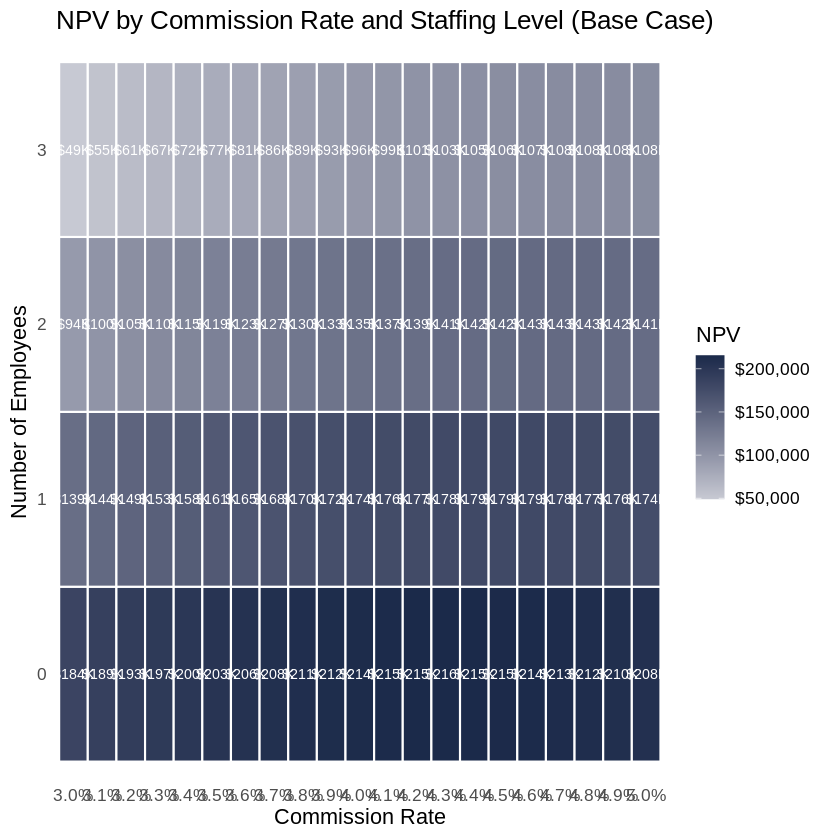

In [ ]:
# ── Heatmap: all 84 combinations (base case NPV) ─────────────────────────────
ggplot(grid, aes(x = percent(commission, 0.1),
                  y = factor(employees),
                  fill = npv_base)) +
  geom_tile(color = "white", linewidth = 0.6) +
  geom_text(aes(label = dollar(npv_base, scale = 1e-3, suffix = "K",
                               accuracy = 1)),
            size = 3, color = "white") +
  scale_fill_gradient2(
    low     = "#CC0000",
    mid     = "white",
    high    = "#1B2A4A",
    midpoint = 0,
    labels  = dollar
  ) +
  labs(
    title = "NPV by Commission Rate and Staffing Level (Base Case)",
    x     = "Commission Rate",
    y     = "Number of Employees",
    fill  = "NPV"
  ) +
  theme_minimal(base_size = 13) +
  theme(panel.grid = element_blank())

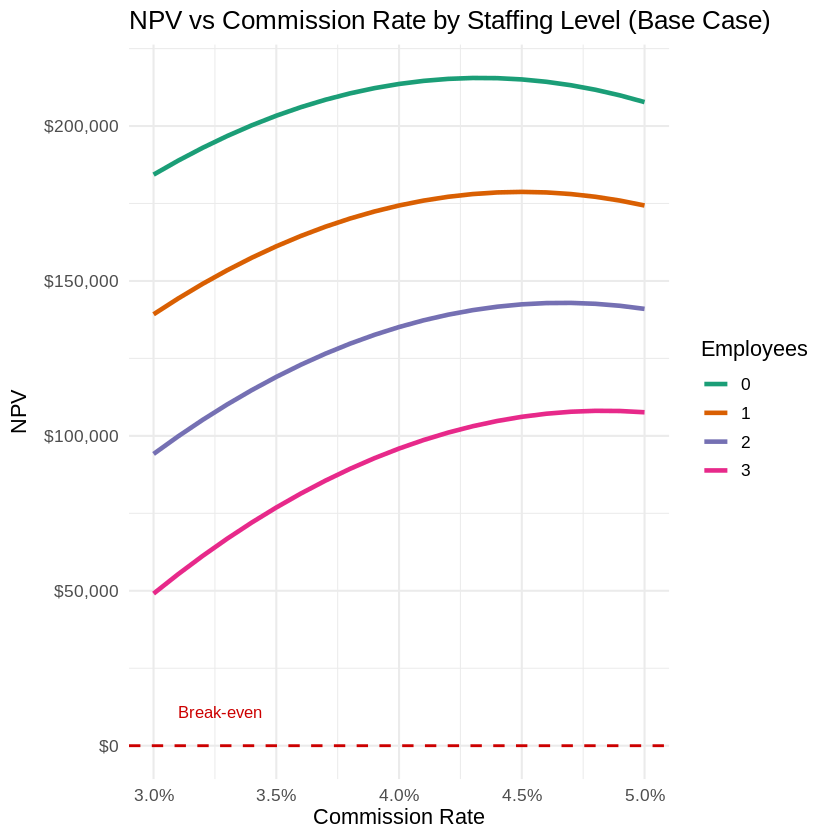

In [ ]:
# ── Line chart: NPV vs commission rate, one line per staffing level ──────────
ggplot(grid, aes(x     = commission,
                  y     = npv_base,
                  color = factor(employees),
                  group = factor(employees))) +
  geom_line(linewidth = 1.3) +
  geom_hline(yintercept = 0, linetype = "dashed",
             color = "#CC0000", linewidth = 0.8) +
  annotate("text", x = 0.031, y = max(grid$npv_base) * 0.05,
           label = "Break-even", color = "#CC0000", size = 3.5, hjust = 0) +
  scale_x_continuous(labels = percent) +
  scale_y_continuous(labels = dollar) +
  scale_color_brewer(palette = "Dark2") +
  labs(
    title  = "NPV vs Commission Rate by Staffing Level (Base Case)",
    x      = "Commission Rate",
    y      = "NPV",
    color  = "Employees"
  ) +
  theme_minimal(base_size = 13)

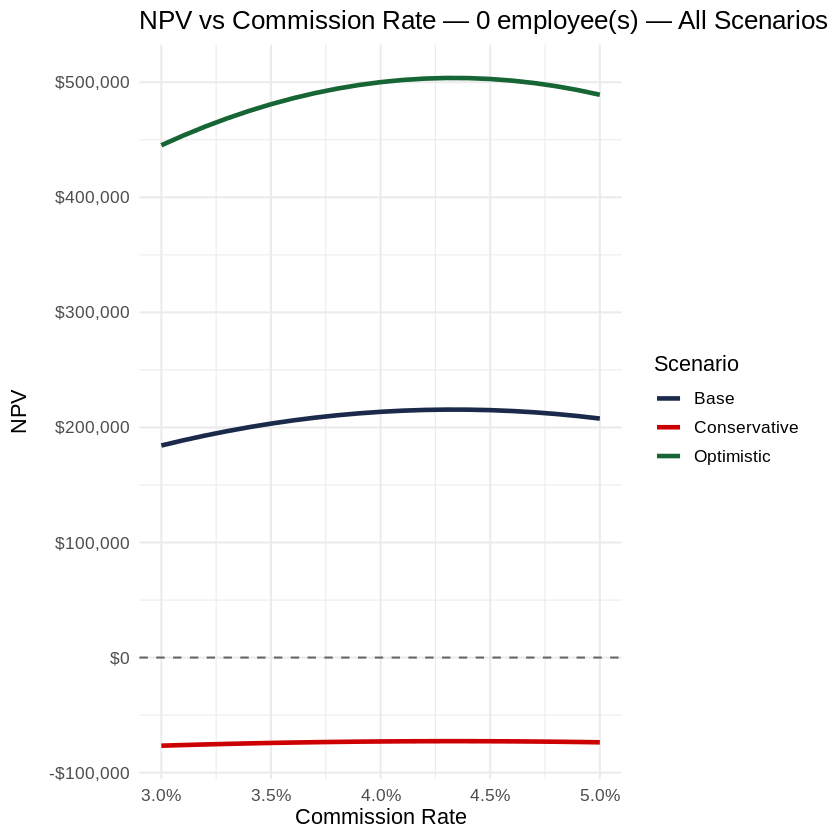

In [ ]:
# ── Optional: overlay all three scenarios on one chart ───────────────────────
# Reshape for ggplot
grid_long <- rbind(
  data.frame(commission = grid$commission, employees = grid$employees,
             npv = grid$npv_base, scenario = "Base"),
  data.frame(commission = grid$commission, employees = grid$employees,
             npv = grid$npv_low,  scenario = "Conservative"),
  data.frame(commission = grid$commission, employees = grid$employees,
             npv = grid$npv_high, scenario = "Optimistic")
)

# Filter to a single staffing level for clarity (change as needed)
staff_level <- best_base$employees

ggplot(grid_long[grid_long$employees == staff_level, ],
       aes(x = commission, y = npv, color = scenario, group = scenario)) +
  geom_line(linewidth = 1.3) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "grey40") +
  scale_x_continuous(labels = percent) +
  scale_y_continuous(labels = dollar) +
  scale_color_manual(values = c("Base" = "#1B2A4A",
                                 "Conservative" = "#CC0000",
                                 "Optimistic"   = "#166534")) +
  labs(
    title    = paste("NPV vs Commission Rate —", staff_level, "employee(s) — All Scenarios"),
    x        = "Commission Rate",
    y        = "NPV",
    color    = "Scenario"
  ) +
  theme_minimal(base_size = 13)

The visualization charts reveal a clear mathematical boundary for maximizing project returns. In the primary line chart plotting Net Present Value (NPV) against commission rates, the baseline strategy peaks precisely at a 4.3% commission rate when staffed with 0 employees. On either side of this 4.3% optimum, the financial curves slope downward, demonstrating that mispricing the services in either direction degrades value. Moving to a lower commission rate sacrifices too much profit margin per transaction, while pushing to a higher rate triggers a steep drop in market penetration that completely wipes out the pricing premium. Furthermore, the data explicitly demonstrates that adding headcount is financially counterproductive under all pricing structures. In both the heatmap grid and the multi-line chart, the curve representing 0 employees sits completely on top of the other operational layers. Every single staffing addition shifts the entire NPV curve downward across all evaluated commission rates. This occurs because the flat 0.5% market share penetration boost generated by an extra employee fails to bring in enough local transaction volume to clear the rigid $65,000 annual salary hurdle, proving that a lean, zero-employee infrastructure yields the most efficient cost-to-revenue ratio.

Paragraph 1 — Answer and evidence

The firm should open a new office in Canarsie because it yields strong financial returns under normal market conditions, though the decision carries a clear downside risk that must be managed. Under the baseline forecast, the office achieves a maximum Net Present Value (NPV) of  215,512,𝑝𝑟𝑜𝑣𝑖𝑛𝑔𝑡ℎ𝑎𝑡𝑡ℎ𝑒𝑒𝑥𝑝𝑎𝑛𝑠𝑖𝑜𝑛𝑖𝑠ℎ𝑖𝑔ℎ𝑙𝑦𝑝𝑟𝑜𝑓𝑖𝑡𝑎𝑏𝑙𝑒𝑎𝑛𝑑𝑠𝑡𝑟𝑢𝑐𝑡𝑢𝑟𝑎𝑙𝑙𝑦𝑣𝑖𝑎𝑏𝑙𝑒.𝐻𝑜𝑤𝑒𝑣𝑒𝑟,𝑢𝑛𝑑𝑒𝑟𝑡ℎ𝑒𝑐𝑜𝑛𝑠𝑒𝑟𝑣𝑎𝑡𝑖𝑣𝑒𝑓𝑜𝑟𝑒𝑐𝑎𝑠𝑡(𝑡ℎ𝑒𝑙𝑜𝑤𝑒𝑟𝑏𝑜𝑢𝑛𝑑𝑜𝑓𝑡ℎ𝑒95 72,649. While this potential loss requires a strict risk-mitigation strategy, the substantial upside of the base case justifies moving forward with a lean initial launch.

Paragraph 2 — Optimal configuration

The recommended optimal configuration is a 4.3% commission rate with 0 employees, which results in a 6.6% market penetration rate. This specific setup maximizes NPV by finding the ideal competitive balance between profit margin per deal and overall transaction volume. Forcing a higher commission rate would shrink the firm's market share too drastically, while lowering the rate would sacrifice too much fee revenue on the deals captured. Furthermore, the model strictly favors zero salaried employees because the $65,000 annual cost per person creates too high of a financial hurdle; the flat 0.5% market share increase generated by an extra staff member fails to capture enough hyper-local volume to cover their salary, making a lean operational footprint the most profitable strategy.

Paragraph 3 — Uncertainty and reversal

his recommendation flows directly from our earlier market analysis, which identified Canarsie as a remarkably stable middle-market residential hub (boasting a low price-volatility CV of 0.46) whose share of Brooklyn's total sales volume has steadily grown. However, this recommendation does not hold under the conservative forecast. If the market severely contracts, the rigid annual fixed overhead of $118,474 will quickly erode corporate capital. Management must closely track first-quarter transaction volumes; if local market activity slides down the lower-bound trajectory toward a pessimistic floor of ~12 deals rather than our projected baseline of ~43 deals, the firm must execute a pre-planned pivot to freeze operations and exit the market.